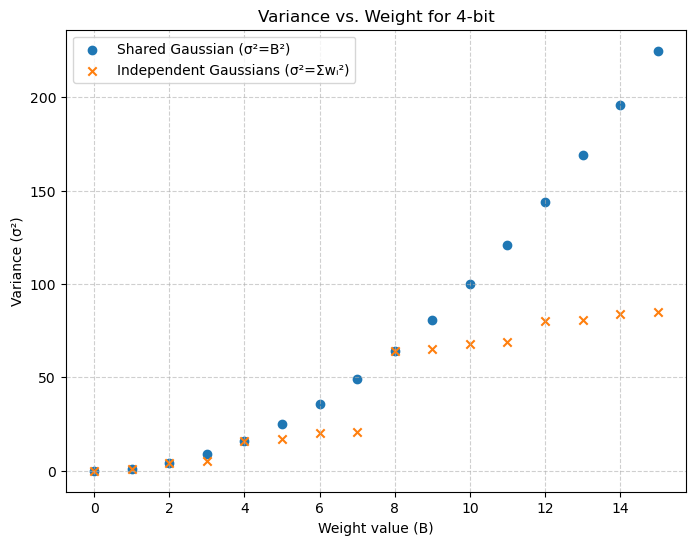

In [3]:
def plot_sigma_vs_weight(num_bits=4):
    weights = [2**i for i in range(num_bits)]

    # 情况A：共享同一个高斯
    xs_shared = []
    ys_shared = []
    for bits in itertools.product([0,1], repeat=num_bits):
        B = sum(b*w for b,w in zip(bits, weights))
        xs_shared.append(B)
        ys_shared.append(B**2)  # 方差

    # 情况B：独立高斯
    xs_indep = []
    ys_indep = []
    for bits in itertools.product([0,1], repeat=num_bits):
        B = sum(b*w for b,w in zip(bits, weights))
        xs_indep.append(B)
        ys_indep.append(sum((b*w)**2 for b,w in zip(bits, weights)))

    plt.figure(figsize=(8,6))
    plt.scatter(xs_shared, ys_shared, label="Shared Gaussian (σ²=B²)", marker="o")
    plt.scatter(xs_indep, ys_indep, label="Independent Gaussians (σ²=Σwᵢ²)", marker="x")

    plt.xlabel("Weight value (B)")
    plt.ylabel("Variance (σ²)")
    plt.title(f"Variance vs. Weight for {num_bits}-bit")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

plot_sigma_vs_weight(4)


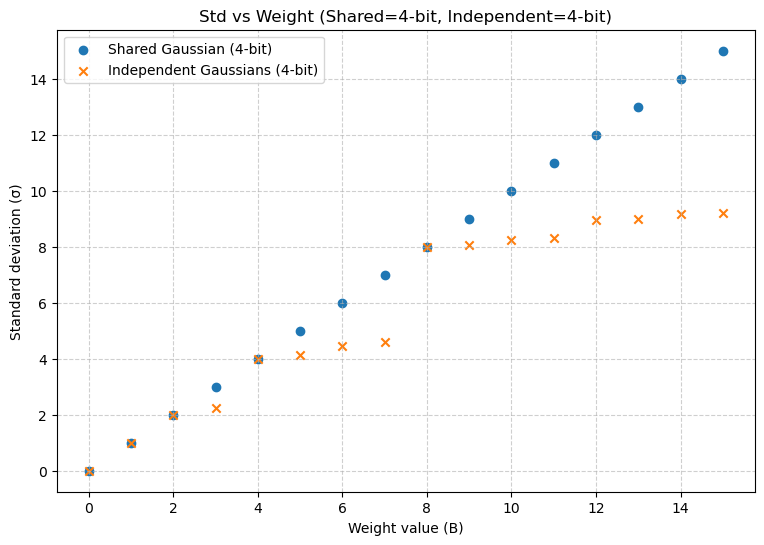

In [62]:
def plot_std_vs_weight_split(shared_bits=4, indep_bits=5):
    # Shared Gaussian case
    weights_shared = [2**i for i in range(shared_bits)]
    xs_shared, ys_shared = [], []
    for bits in itertools.product([0,1], repeat=shared_bits):
        B = sum(b*w for b,w in zip(bits, weights_shared))
        xs_shared.append(B)
        ys_shared.append(abs(B))  # std = |B|

    # # Independent Gaussian case
    weights_indep = [2**i for i in range(indep_bits)]
    # weights_indep = [np.sqrt(i+1) for i in range(indep_bits)]
    xs_indep, ys_indep = [], []
    for bits in itertools.product([0,1], repeat=indep_bits):
        B = sum(b*w for b,w in zip(bits, weights_indep))
        xs_indep.append(B)
        ys_indep.append((sum((b*w)**2 for b,w in zip(bits, weights_indep)))**0.5 * 1)
    xs_indep = xs_shared
    # Plot
    plt.figure(figsize=(9,6))
    plt.scatter(xs_shared, ys_shared, label=f"Shared Gaussian ({shared_bits}-bit)", marker="o")
    plt.scatter(xs_indep, ys_indep, label=f"Independent Gaussians ({indep_bits}-bit)", marker="x")

    plt.xlabel("Weight value (B)")
    plt.ylabel("Standard deviation (σ)")
    plt.title(f"Std vs Weight (Shared={shared_bits}-bit, Independent={indep_bits}-bit)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

plot_std_vs_weight_split(shared_bits=4, indep_bits=4)


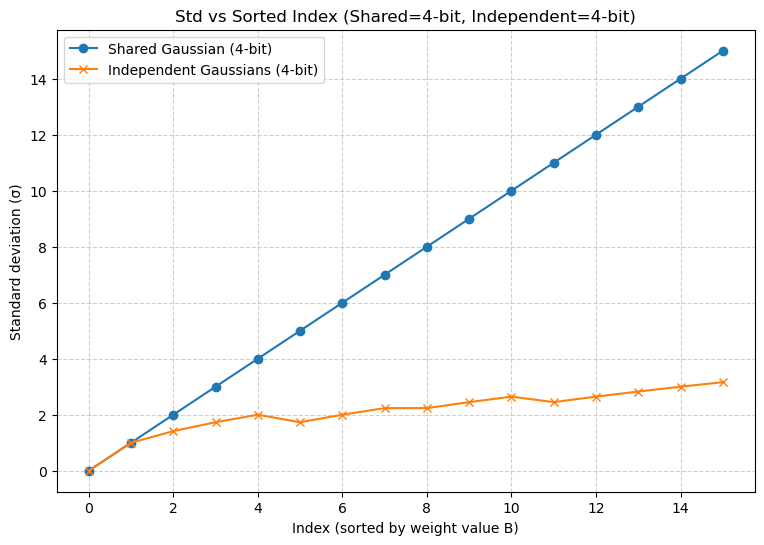

In [35]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

def plot_std_vs_index(shared_bits=4, indep_bits=4):
    # Shared Gaussian case
    weights_shared = [2**i for i in range(shared_bits)]
    data_shared = []
    for bits in itertools.product([0,1], repeat=shared_bits):
        B = sum(b*w for b,w in zip(bits, weights_shared))
        sigma = abs(B)  # std = |B|
        data_shared.append((B, sigma))
    data_shared.sort(key=lambda x: x[0])  # 按 B 排序
    xs_shared = list(range(len(data_shared)))
    ys_shared = [s for _, s in data_shared]

    # Independent Gaussian case
    weights_indep = [np.sqrt(i+1) for i in range(indep_bits)]
    data_indep = []
    for bits in itertools.product([0,1], repeat=indep_bits):
        B = sum(b*w for b,w in zip(bits, weights_indep))
        sigma = (sum((b*w)**2 for b,w in zip(bits, weights_indep)))**0.5 * 1
        data_indep.append((B, sigma))
    data_indep.sort(key=lambda x: x[0])  # 按 B 排序
    xs_indep = list(range(len(data_indep)))
    ys_indep = [s for _, s in data_indep]

    # Plot
    plt.figure(figsize=(9,6))
    plt.plot(xs_shared, ys_shared, "o-", label=f"Shared Gaussian ({shared_bits}-bit)")
    plt.plot(xs_indep, ys_indep, "x-", label=f"Independent Gaussians ({indep_bits}-bit)")

    plt.xlabel("Index (sorted by weight value B)")
    plt.ylabel("Standard deviation (σ)")
    plt.title(f"Std vs Sorted Index (Shared={shared_bits}-bit, Independent={indep_bits}-bit)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

plot_std_vs_index(shared_bits=4, indep_bits=4)


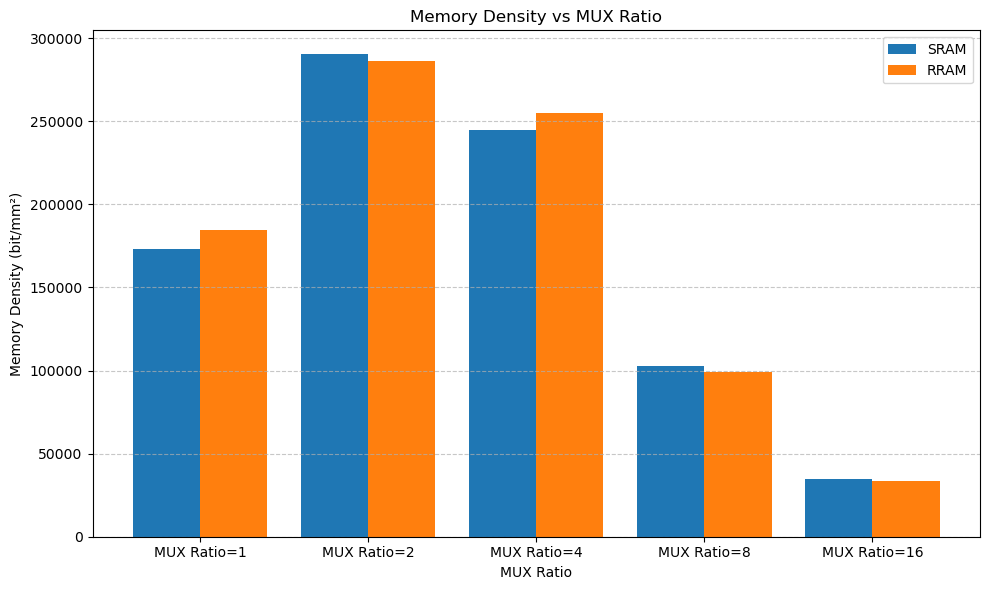

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['MUX Ratio=1', 'MUX Ratio=2', 'MUX Ratio=4', 'MUX Ratio=8', 'MUX Ratio=16']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [244875.9680166254, 279786.8825978761, 314369.53191914305, 344477.14503968216, 369499.9051086005]
bits_per_mm2_rram = [254995.5734040292, 314290.8057518513, 380846.85061223357, 447918.6535393265, 511632.31794039067]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='RRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('Memory Density (bit/mm²)')
plt.title('Memory Density vs MUX Ratio')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

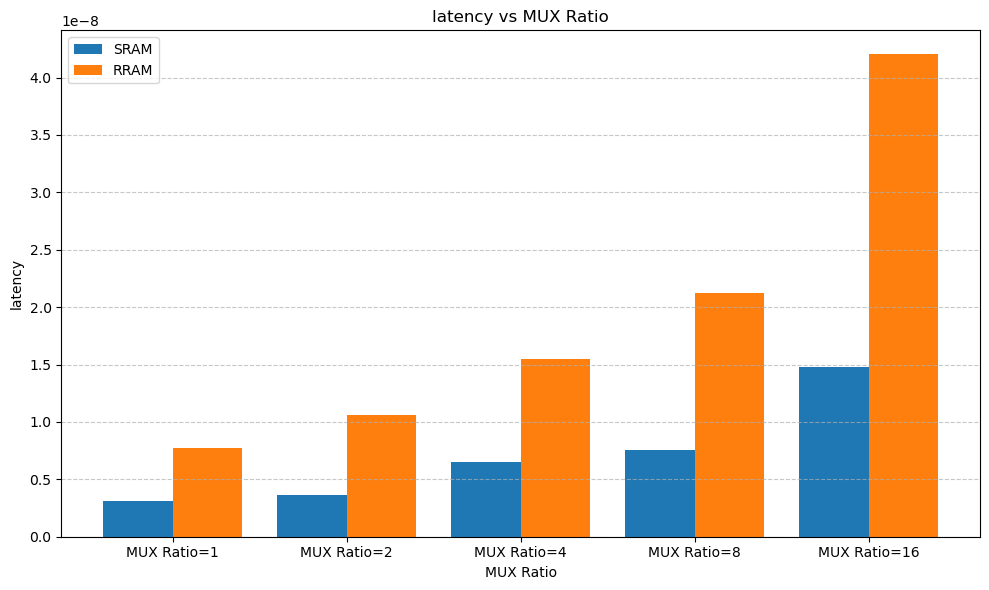

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['MUX Ratio=1', 'MUX Ratio=2', 'MUX Ratio=4', 'MUX Ratio=8', 'MUX Ratio=16']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [6.540034062311529e-09, 2.2543712850354326e-08, 3.967058280715171e-08, 7.324192443035757e-08, 1.4392202714971988e-07]
bits_per_mm2_rram = [1.5467813913817002e-08, 2.2543712850354326e-08, 9.201349506920435e-08, 1.7792774895446284e-07, 5.109772585977787e-08]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='RRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('MUX Ratio')
plt.ylabel('latency')
plt.title('latency vs MUX Ratio')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

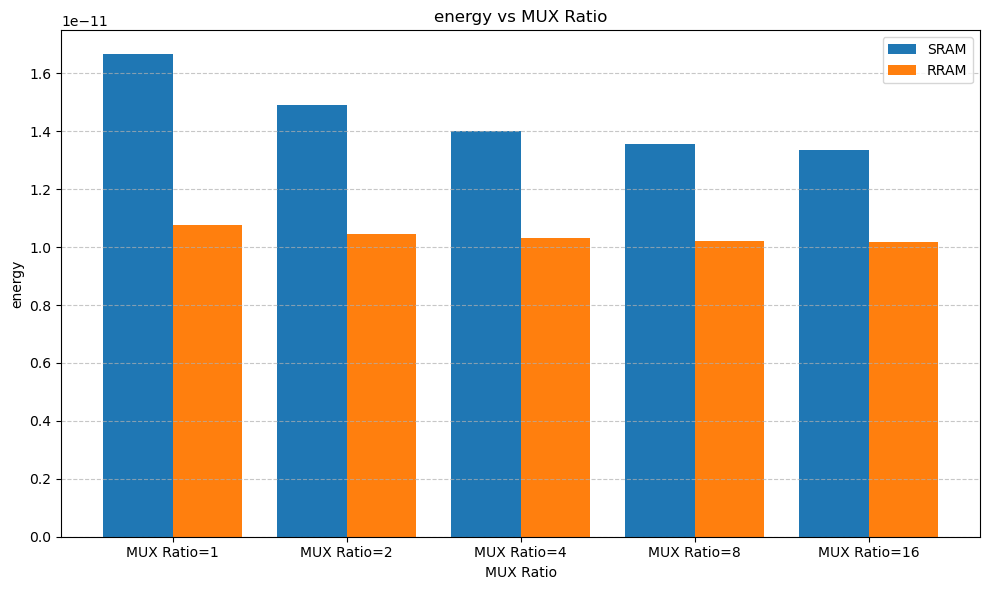

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['MUX Ratio=1', 'MUX Ratio=2', 'MUX Ratio=4', 'MUX Ratio=8', 'MUX Ratio=16']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [1.014633197221977e-11, 1.3423678240891251e-11, 1.6655836901952193e-11, 2.4600627669936684e-11, 5.908005284243529e-11]
bits_per_mm2_rram = [8.047e-12, 9.170e-12, 1.075e-11, 1.269e-11, 2.178e-11]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='RRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('energy')
plt.title('energy vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

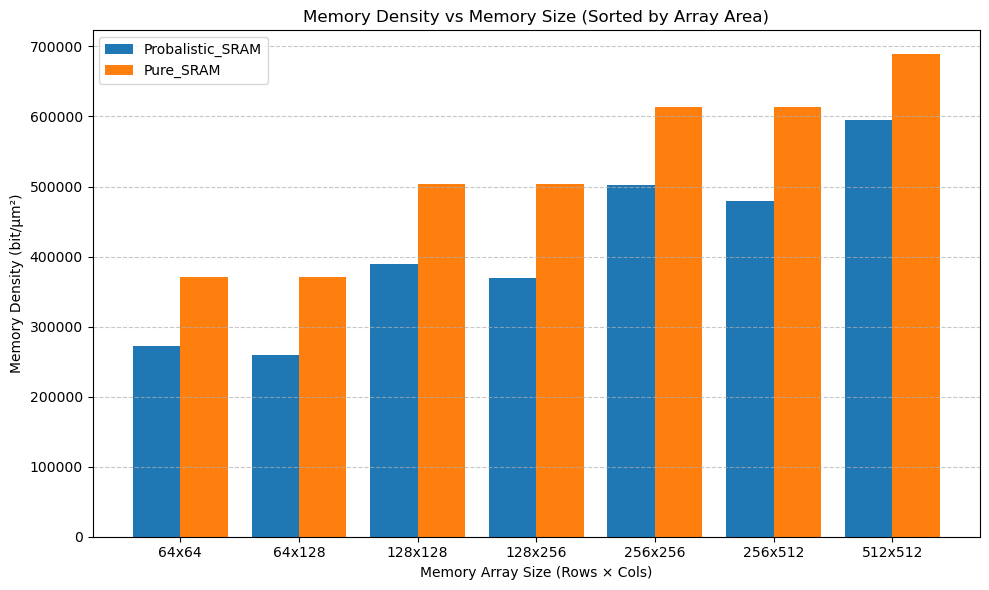

In [24]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# 数据文件目录
ps_sram_data_folder = "./Data/simulation/ps_sram"
ps_sram_files = [f for f in os.listdir(ps_sram_data_folder) if f.endswith(".json")]

pure_sram_data_folder = "./Data/simulation/pure_sram"
pure_sram_files = [f for f in os.listdir(pure_sram_data_folder) if f.endswith(".json")]

# 临时存储所有数据
data_list_ps = []
data_list_pure_sram = []

# 读取所有 JSON 文件
for file in ps_sram_files:
    filepath = os.path.join(ps_sram_data_folder, file)
    with open(filepath, "r") as f:
        data = json.load(f)

    num_rows = data["num_rows"]
    num_cols = data["num_cols"]
    density = data["memory_density (bits/um^2)"]

    data_list_ps.append({
        "label": f"{num_rows}x{num_cols}",
        "rows": num_rows,
        "cols": num_cols,
        "area": num_rows * num_cols,
        "density": density
    })
for file in pure_sram_files:
    filepath = os.path.join(pure_sram_data_folder, file)
    with open(filepath, "r") as f:
        data = json.load(f)

    num_rows = data["num_rows"]
    num_cols = data["num_cols"]
    density = data["memory_density (bits/um^2)"]

    data_list_pure_sram.append({
        "label": f"{num_rows}x{num_cols}",
        "rows": num_rows,
        "cols": num_cols,
        "area": num_rows * num_cols,
        "density": density
    })
    

# ✅ 按面积从小到大排序
data_list_ps.sort(key=lambda d: d["area"])
data_list_pure_sram.sort(key=lambda d: d["area"])

# 分离数据用于绘图
memory_sizes = [d["label"] for d in data_list_ps]
memory_density_sram_ps = [d["density"] for d in data_list_ps]

memory_density_sram_pure = [d["density"] for d in data_list_pure_sram]

# 绘图
x = np.arange(len(memory_sizes))
bar_width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, memory_density_sram_ps, width=bar_width, label="Probalistic_SRAM")
plt.bar(x + bar_width/2, memory_density_sram_pure, width=bar_width, label="Pure_SRAM")

# 坐标轴与标题
plt.xticks(x, memory_sizes)
plt.xlabel("Memory Array Size (Rows × Cols)")
plt.ylabel("Memory Density (bit/μm²)")
plt.title("Memory Density vs Memory Size (Sorted by Array Area)")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

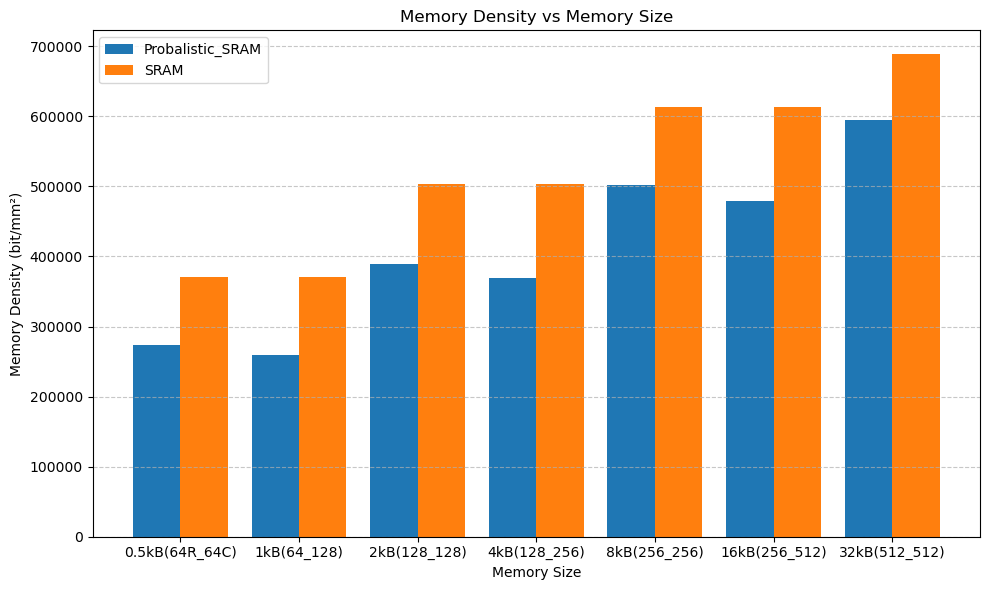

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['0.5kB(64R_64C)', '1kB(64_128)', '2kB(128_128)', '4kB(128_256)', '8kB(256_256)', '16kB(256_512)', '32kB(512_512)']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [272891.5158663153, 259094.4315972537, 389506.56467847107, 369549.4980352537,502373.4064146343, 478754.0416695071, 594555.0271741371]
bits_per_mm2_rram = [371024.94207962777, 371225.03565538063, 503919.3798094217, 504011.62301843695, 613650.1138615856, 613684.3069741451, 688561.2345703738]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='Probalistic_SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='SRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('Memory Density (bit/mm²)')
plt.title('Memory Density vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

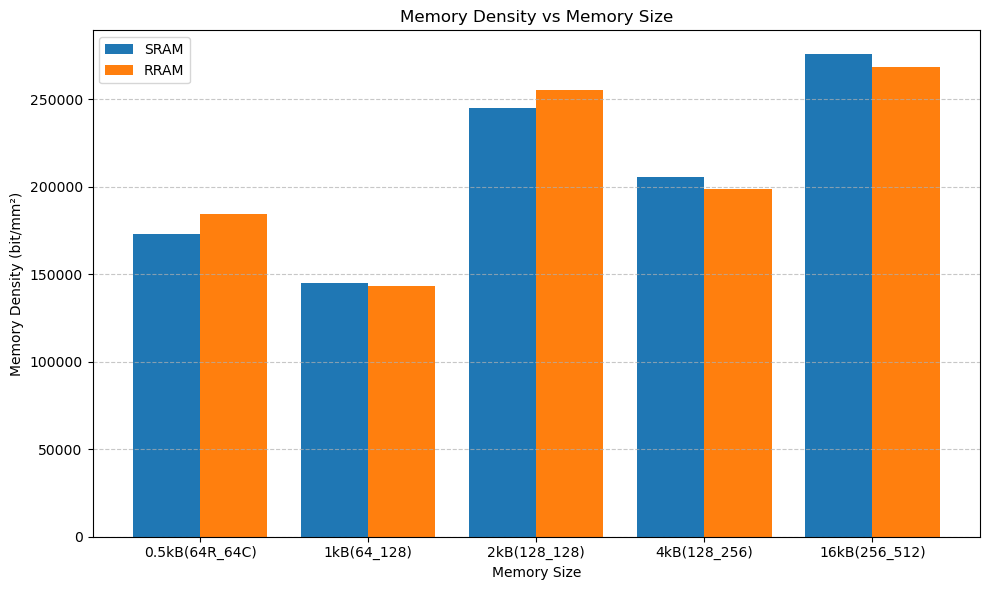

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['0.5kB(64R_64C)', '1kB(64_128)', '2kB(128_128)', '4kB(128_256)', '16kB(256_512)']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [172960.42849724338, 145089.55128132328, 244875.9680166254, 205351.6648260122, 275607.4815655287]
bits_per_mm2_rram = [184485.27308804495, 142995.98362562724, 254995.5734040292, 198660.42344459047, 268222.29248234705]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='RRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('Memory Density (bit/mm²)')
plt.title('Memory Density vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

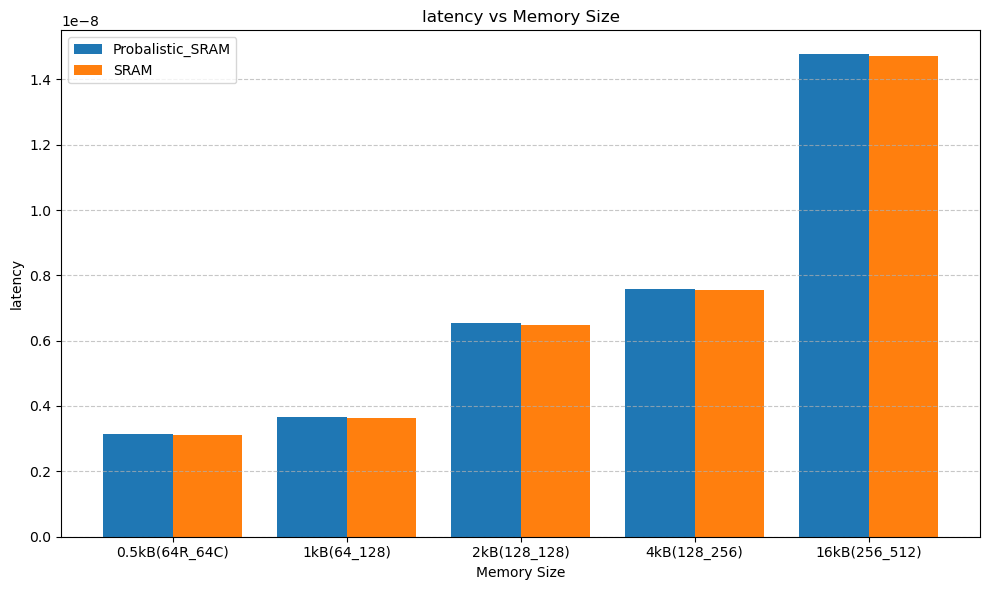

In [146]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['0.5kB(64R_64C)', '1kB(64_128)', '2kB(128_128)', '4kB(128_256)', '16kB(256_512)']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [3.148778382740972e-09, 3.6724829883030754e-09, 6.540034062311529e-09, 7.587443273435738e-09, 1.4764751759080947e-08]
bits_per_mm2_rram = [3.098775858590459e-09, 3.6224804641525626e-09, 6.490031538161017e-09, 7.537440749285226e-09, 1.4714749234930434e-08]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='Probalistic_SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='SRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('latency')
plt.title('latency vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

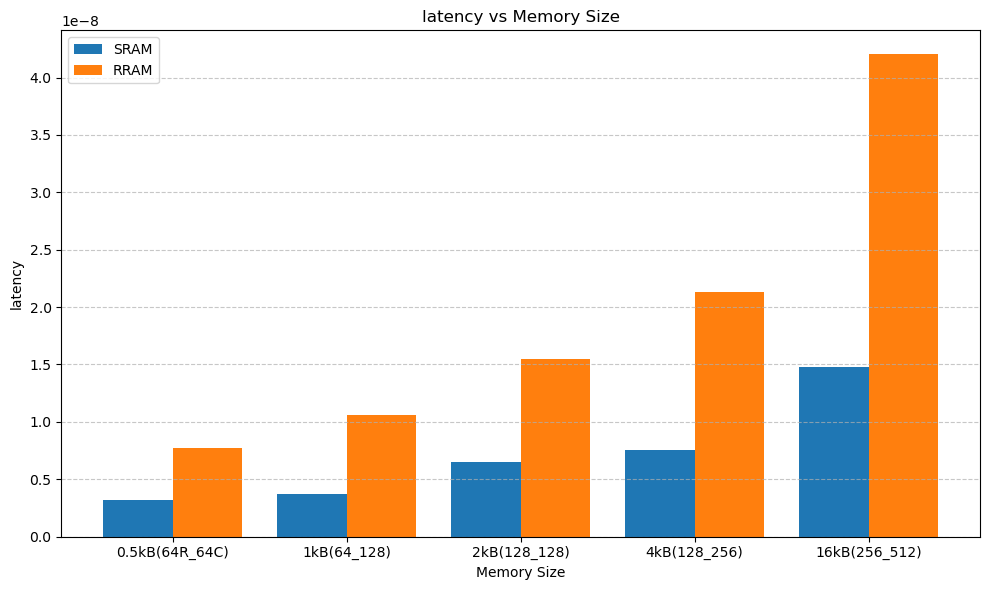

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['0.5kB(64R_64C)', '1kB(64_128)', '2kB(128_128)', '4kB(128_256)', '16kB(256_512)']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [3.148778382740972e-09, 3.6724829883030754e-09, 6.540034062311529e-09, 7.587443273435738e-09, 1.4764751759080947e-08]
bits_per_mm2_rram = [7.722941777985035e-09, 1.061630416702411e-08, 1.5467813913817002e-08, 2.1274559540671078e-08, 4.20176585431785e-08]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='RRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('latency')
plt.title('latency vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

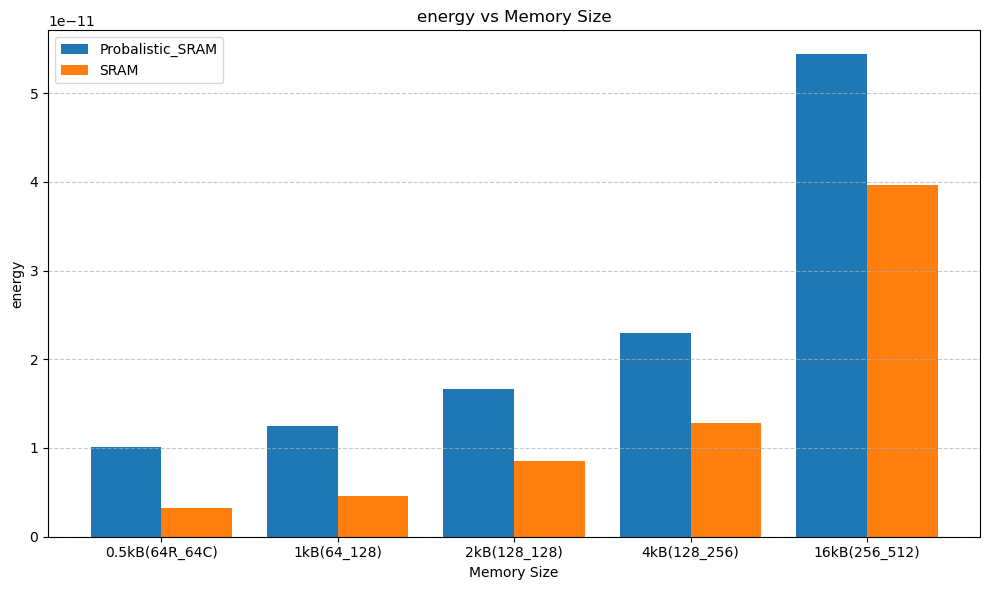

In [148]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['0.5kB(64R_64C)', '1kB(64_128)', '2kB(128_128)', '4kB(128_256)', '16kB(256_512)']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [1.014633197221977e-11, 1.2469905576920942e-11, 1.6655836901952193e-11, 2.294295473302276e-11, 5.4365001839465645e-11]
bits_per_mm2_rram = [3.265820151565038e-12, 4.559075085821603e-12 , 8.549698168572555e-12, 1.2776178658753908e-11, 3.968633459885775e-11]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='Probalistic_SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='SRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('energy')
plt.title('energy vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

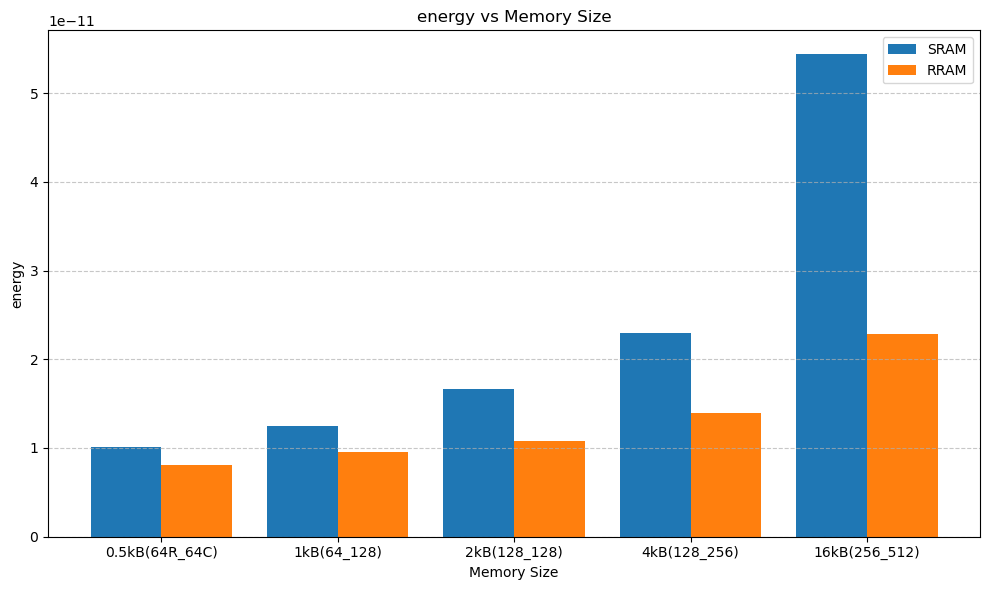

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['0.5kB(64R_64C)', '1kB(64_128)', '2kB(128_128)', '4kB(128_256)', '16kB(256_512)']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [1.014633197221977e-11, 1.2469905576920942e-11, 1.6655836901952193e-11, 2.294295473302276e-11, 5.4365001839465645e-11]
bits_per_mm2_rram = [8.047e-12, 9.576e-12 , 1.075e-11, 1.392e-11, 2.286e-11]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='RRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('energy')
plt.title('energy vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

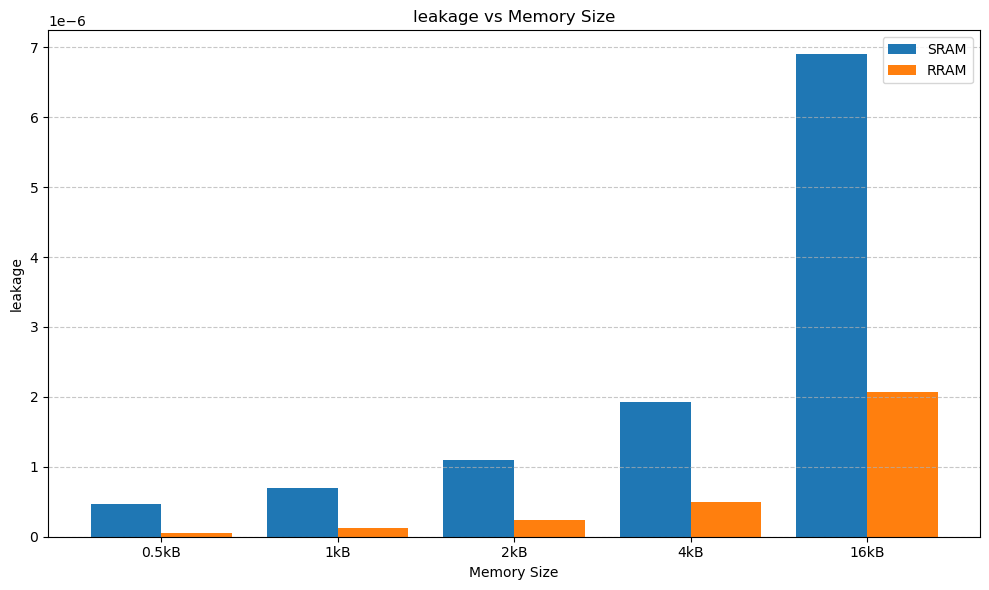

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 memory size（单位：kB）
memory_sizes = ['0.5kB', '1kB', '2kB', '4kB', '16kB']

# 对应的 memory density（bit/mm²）
bits_per_mm2_sram = [4.739e-07, 6.982e-07, 1.102e-06, 1.927e-06, 6.897e-06]
bits_per_mm2_rram = [5.626e-08, 1.211e-07, 2.411e-07, 4.992e-07, 2.067e-06]

# 横坐标位置
x = np.arange(len(memory_sizes))
bar_width = 0.4

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, bits_per_mm2_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, bits_per_mm2_rram, width=bar_width, label='RRAM')

# 设置标签和标题
plt.xticks(x, memory_sizes)
plt.xlabel('Memory Size')
plt.ylabel('leakage')
plt.title('leakage vs Memory Size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

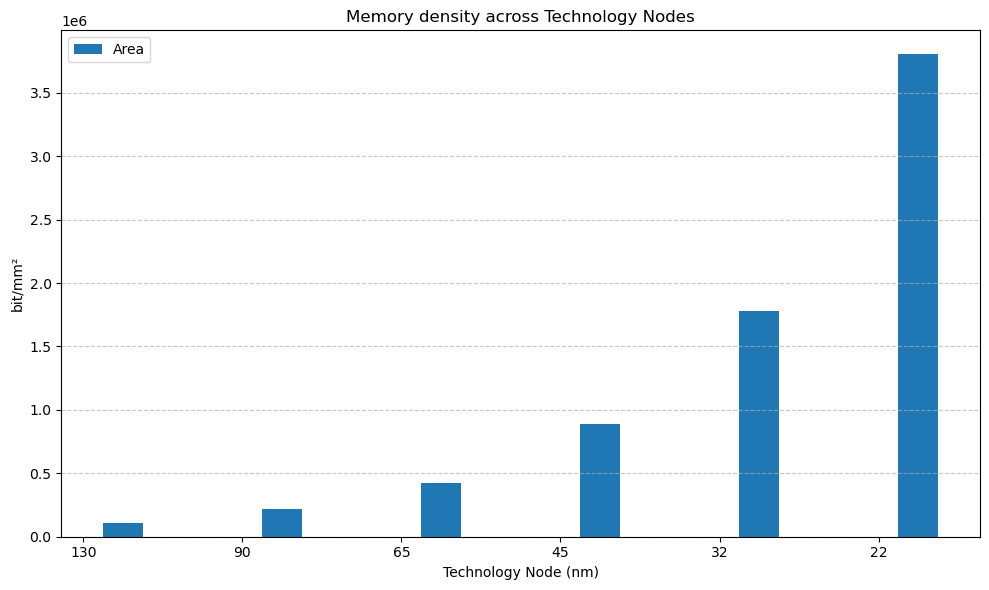

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = [130, 90, 65, 45, 32, 22]

# 对应的数据
# width = [0.00037, 0.00025, 0.00018, 0.00012, 9.13408e-05, 6.27968e-05]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
area = [104813.9, 221850.5, 426586, 890458, 1777823.2, 3802198.9]
# area = [265284.8, 563671.1, 1084727.98, 2264557.38, 4533068.3, 9723825.6]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
# plt.bar(x - bar_width, width, width=bar_width, label='Width')
# plt.bar(x, height, width=bar_width, label='Height')
plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Technology Node (nm)')
plt.ylabel('bit/mm²')
plt.title('Memory density across Technology Nodes')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


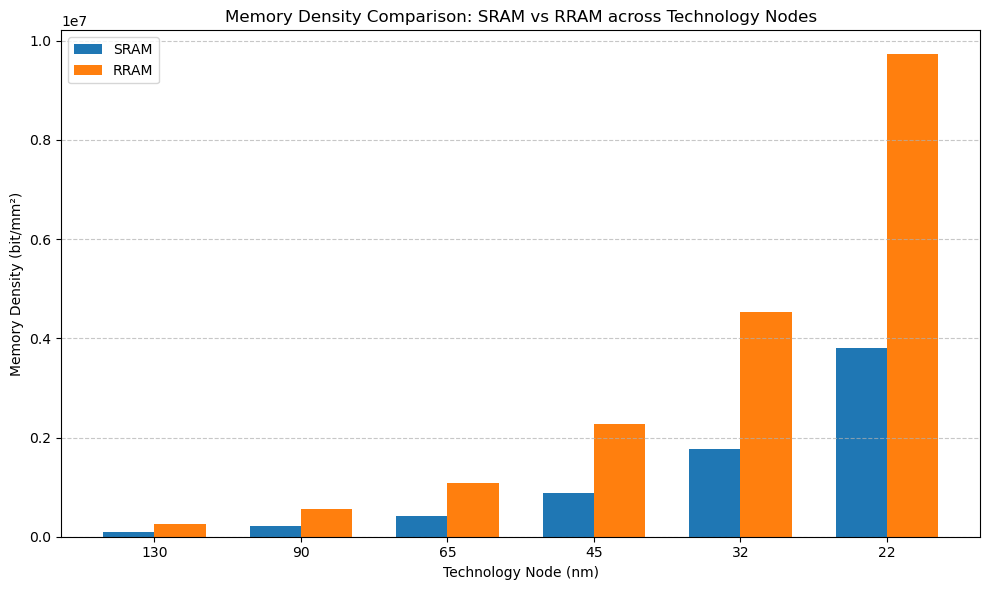

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = [130, 90, 65, 45, 32, 22]

# SRAM memory density（bit/mm²）
area_sram = [104813.9, 221850.5, 426586, 890458, 1777823.2, 3802198.9]

# RRAM memory density（bit/mm²）
area_rram = [265284.8, 563671.1, 1084727.98, 2264557.38, 4533068.3, 9723825.6]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.35

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, area_sram, width=bar_width, label='SRAM')
plt.bar(x + bar_width/2, area_rram, width=bar_width, label='RRAM')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Technology Node (nm)')
plt.ylabel('Memory Density (bit/mm²)')
plt.title('Memory Density Comparison: SRAM vs RRAM across Technology Nodes')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


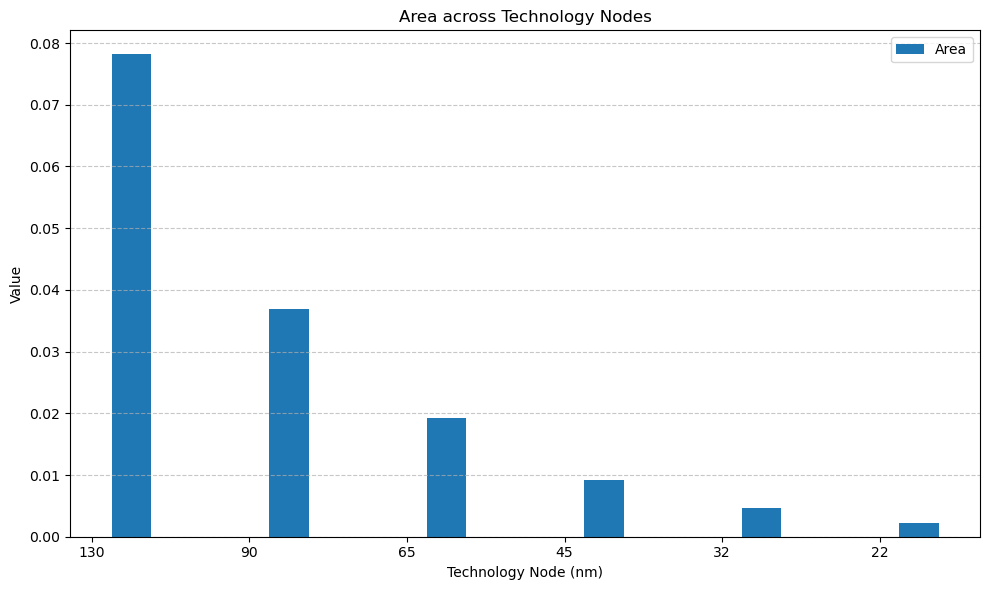

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = [130, 90, 65, 45, 32, 22]

# 对应的数据
# width = [0.00037, 0.00025, 0.00018, 0.00012, 9.13408e-05, 6.27968e-05]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
area = [0.0781575349751751, 0.036925754861300425, 0.01920362517603389, 0.009199758326776969, 0.004607882226790644, 0.0021545427191303353]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
# plt.bar(x - bar_width, width, width=bar_width, label='Width')
# plt.bar(x, height, width=bar_width, label='Height')
plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Technology Node (nm)')
plt.ylabel('Value')
plt.title('Area across Technology Nodes')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


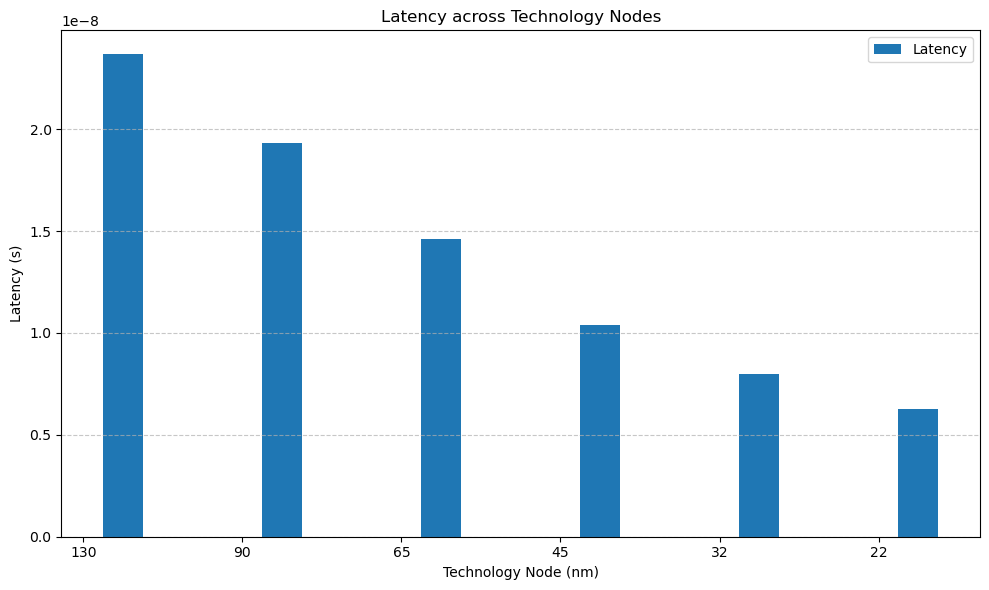

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = [130, 90, 65, 45, 32, 22]

# 对应的数据
# width = [0.00037, 0.00025, 0.00018, 0.00012, 9.13408e-05, 6.27968e-05]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
area = [2.367272182768412e-08, 1.9326465308452133e-08, 1.4628754219952013e-08, 1.040977820571037e-08, 8.01014641202208e-09, 6.280719921042295e-09]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
# plt.bar(x - bar_width, width, width=bar_width, label='Width')
# plt.bar(x, height, width=bar_width, label='Height')
plt.bar(x + bar_width, area, width=bar_width, label='Latency')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Technology Node (nm)')
plt.ylabel('Latency (s)')
plt.title('Latency across Technology Nodes')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


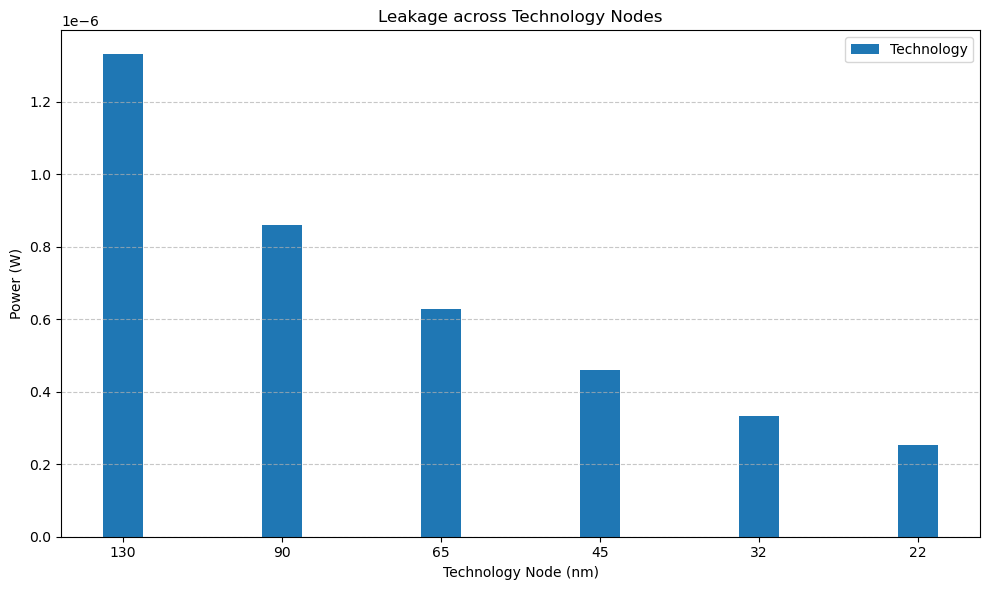

In [102]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = [130, 90, 65, 45, 32, 22]

# 对应的数据
width = [1.330e-06, 8.587e-07, 6.292e-07, 4.590e-07, 3.320e-07, 2.527e-07]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
# area = [0.1338, 0.0629, 0.03155, 0.01438, 0.00725, 0.003420]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, width, width=bar_width, label='Technology')
# plt.bar(x, height, width=bar_width, label='Height')
# plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Technology Node (nm)')
plt.ylabel('Power (W)')
plt.title('Leakage across Technology Nodes')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


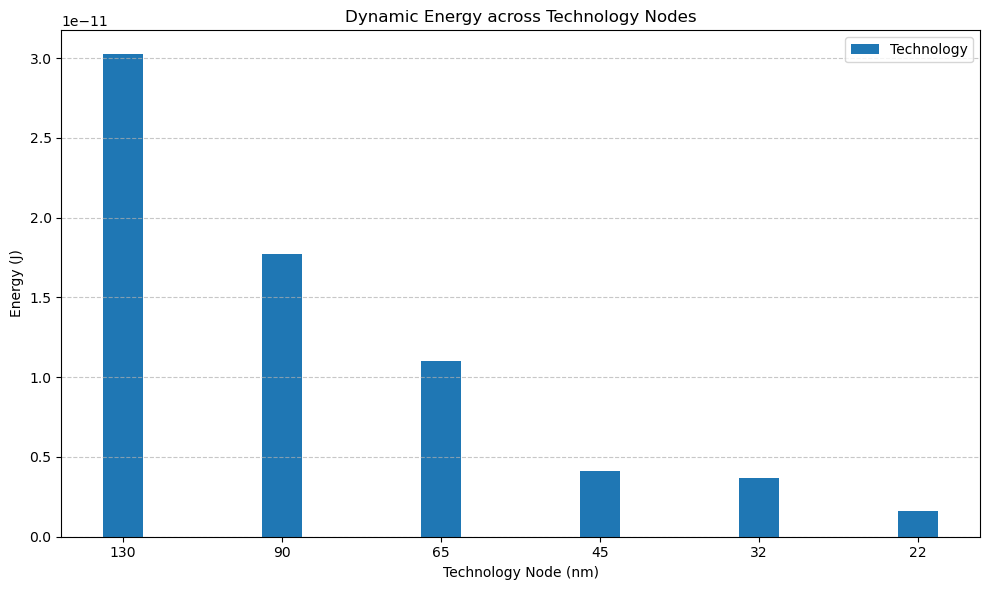

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = [130, 90, 65, 45, 32, 22]

# 对应的数据
width = [3.023520129607674e-11, 1.7697828814297786e-11, 1.1021457532383172e-11 , 4.1055628037626484e-12 , 3.694954923245264e-12, 1.596806617780345e-12]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
# area = [0.1338, 0.0629, 0.03155, 0.01438, 0.00725, 0.003420]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, width, width=bar_width, label='Technology')
# plt.bar(x, height, width=bar_width, label='Height')
# plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Technology Node (nm)')
plt.ylabel('Energy (J)')
plt.title('Dynamic Energy across Technology Nodes')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = [130, 90, 65, 45, 32, 22]

# 对应的数据
width = [0.00037, 0.00025, 0.00018, 0.00012, 9.13408e-05, 6.27968e-05]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
# area = [0.1338, 0.0629, 0.03155, 0.01438, 0.00725, 0.003420]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, width, width=bar_width, label='Width')
# plt.bar(x, height, width=bar_width, label='Height')
# plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Technology Node (nm)')
plt.ylabel('Value')
plt.title('Width, Height, and Area across Technology Nodes')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


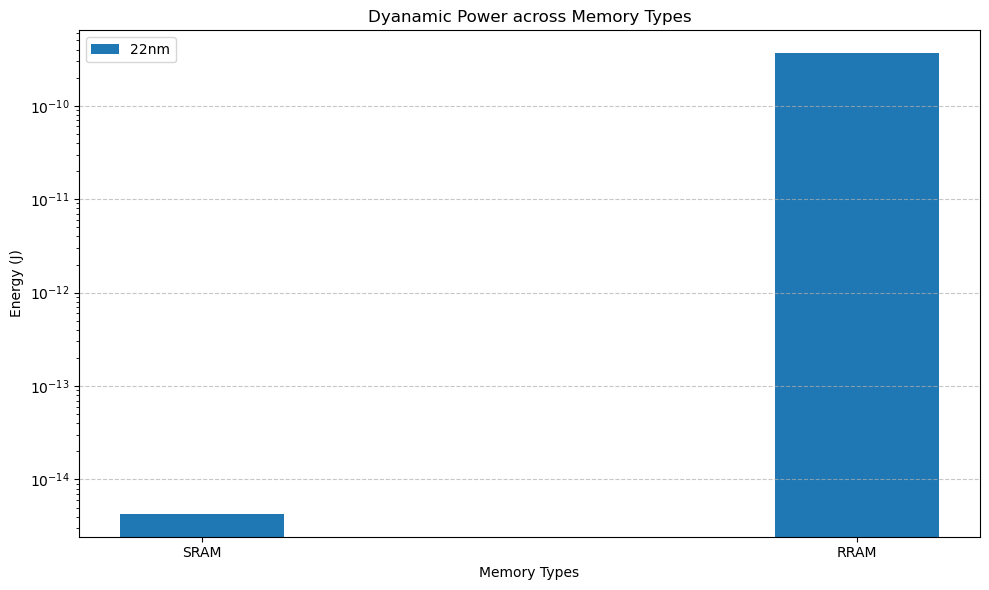

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = ['SRAM', 'RRAM']

# 对应的数据
width = [4.303e-15, 3.639e-10]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
# area = [0.1338, 0.0629, 0.03155, 0.01438, 0.00725, 0.003420]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, width, width=bar_width, label='22nm')
# plt.bar(x, height, width=bar_width, label='Height')
# plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Memory Types')
plt.ylabel('Energy (J)')
plt.title('Dyanamic Power across Memory Types')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.yscale("log")
plt.tight_layout()
plt.show()


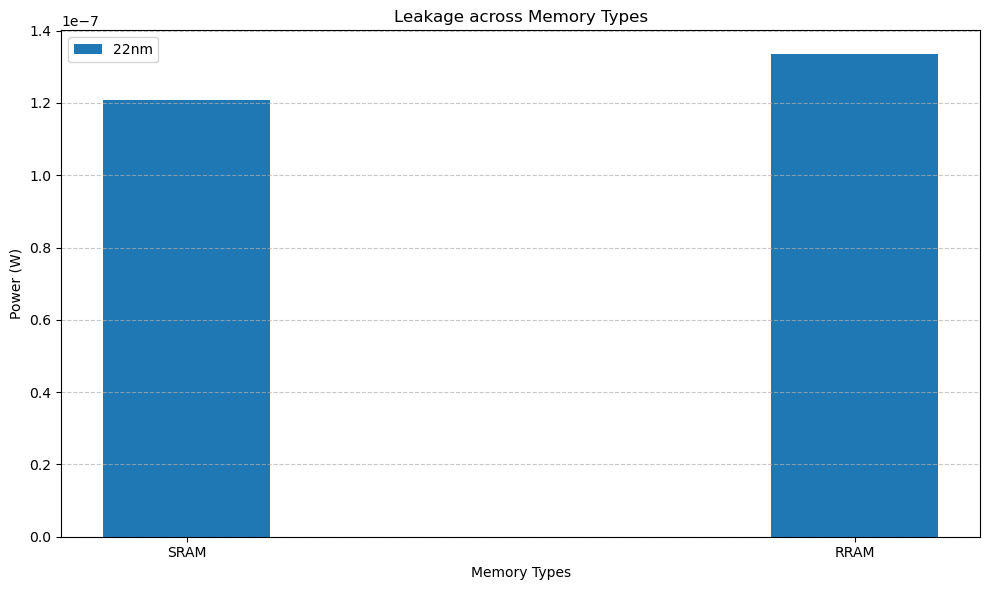

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = ['SRAM', 'RRAM']

# 对应的数据
width = [1.208e-07, 1.334e-07]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
# area = [0.1338, 0.0629, 0.03155, 0.01438, 0.00725, 0.003420]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, width, width=bar_width, label='22nm')
# plt.bar(x, height, width=bar_width, label='Height')
# plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Memory Types')
plt.ylabel('Power (W)')
plt.title('Leakage across Memory Types')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


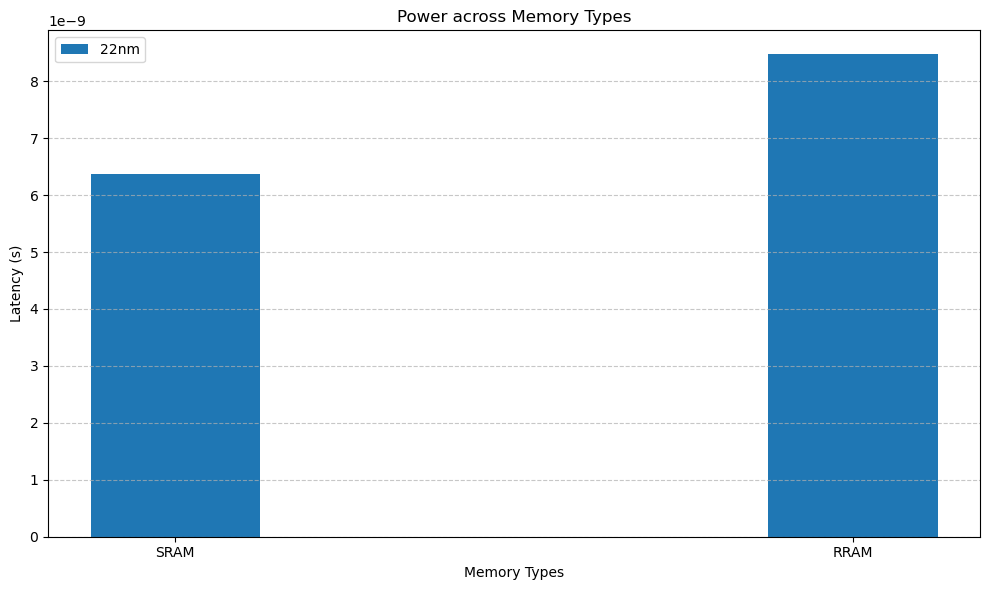

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 工艺节点（从大到小）
technology = ['SRAM', 'RRAM']

# 对应的数据
width = [6.377387259312335e-09, 8.470308103823669e-09]
# height = [0.00036, 0.000245, 0.000170, 0.00011, 7.942538890268936e-05, 5.447016539972032e-05]
# area = [0.1338, 0.0629, 0.03155, 0.01438, 0.00725, 0.003420]

# 横坐标位置
x = np.arange(len(technology))

# 柱子宽度
bar_width = 0.25

# 创建柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, width, width=bar_width, label='22nm')
# plt.bar(x, height, width=bar_width, label='Height')
# plt.bar(x + bar_width, area, width=bar_width, label='Area')

# 添加标签和标题
plt.xticks(x, technology)
plt.xlabel('Memory Types')
plt.ylabel('Latency (s)')
plt.title('Power across Memory Types')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


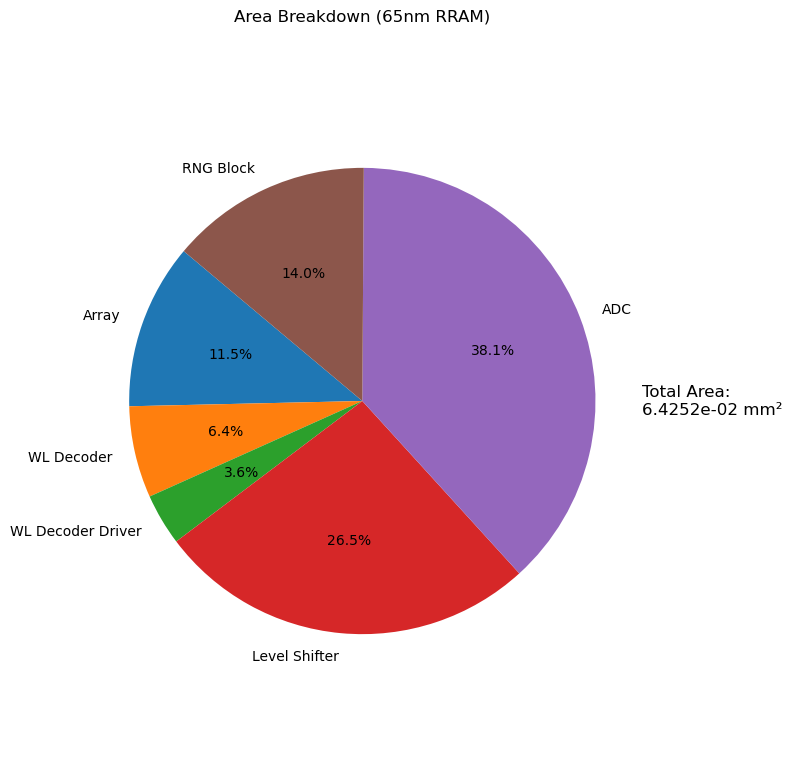

In [7]:
import matplotlib.pyplot as plt

# 各模块名称
labels = [
    'Array',
    'WL Decoder',
    'WL Decoder Driver',
    'Level Shifter',
    'MUX',
    'ADC',
    'RNG Block'
]

# 对应面积数据
areas = [
    3.3226751999999997e-09,
    1.8413158399999993e-09,
    1.03574016e-09,
    7.664477184e-09,
    0,
    1.104789504e-08 ,
    4.051878272e-09
]

total_area = 0.06425209575713017
# 过滤掉面积为 0 的模块（例如 MUX）
filtered_labels = [label for label, area in zip(labels, areas) if area > 0]
filtered_areas = [area for area in areas if area > 0]

# 绘制饼图
plt.figure(figsize=(8, 8))
plt.pie(filtered_areas, labels=filtered_labels, autopct='%1.1f%%', startangle=140)
plt.title('Area Breakdown (65nm RRAM)')
plt.text(1.2, 0.0, f'Total Area:\n{total_area:.4e} mm²', fontsize=12, verticalalignment='center')
plt.axis('equal')  # 让饼图看起来是圆形的
plt.tight_layout()
plt.show()


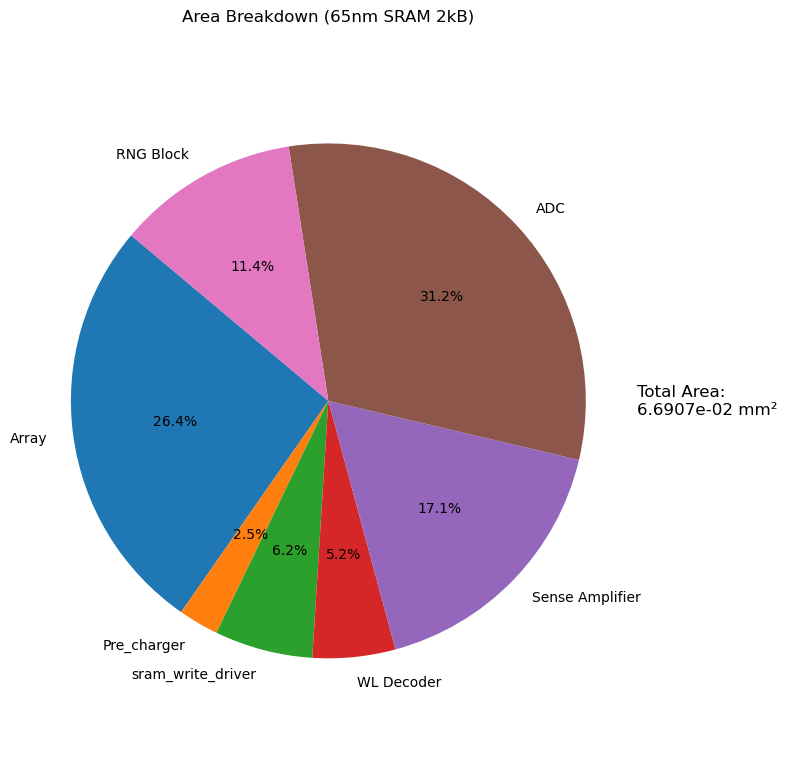

In [9]:
import matplotlib.pyplot as plt

# 各模块名称
labels = [
    'Array',
    'Pre_charger',
    'sram_write_driver',
    'WL Decoder',
    'MUX',
    'Sense Amplifier',
    'ADC',
    'RNG Block'
]

# 对应面积数据
areas = [
    9.370211760000001e-09,
    8.976414719999999e-10,
    2.1865625599999998e-09,
    1.8413158399999993e-09,
    0,
    6.06879e-09,
    1.1047895039999996e-08,
    4.051878272e-09
]

total_area = 0.06690734142963199
# 过滤掉面积为 0 的模块（例如 MUX）
filtered_labels = [label for label, area in zip(labels, areas) if area > 0]
filtered_areas = [area for area in areas if area > 0]

# 绘制饼图
plt.figure(figsize=(8, 8))
plt.pie(filtered_areas, labels=filtered_labels, autopct='%1.1f%%', startangle=140)
plt.title('Area Breakdown (65nm SRAM 2kB)')
plt.text(1.2, 0.0, f'Total Area:\n{total_area:.4e} mm²', fontsize=12, verticalalignment='center')
plt.axis('equal')  # 让饼图看起来是圆形的
plt.tight_layout()
plt.show()


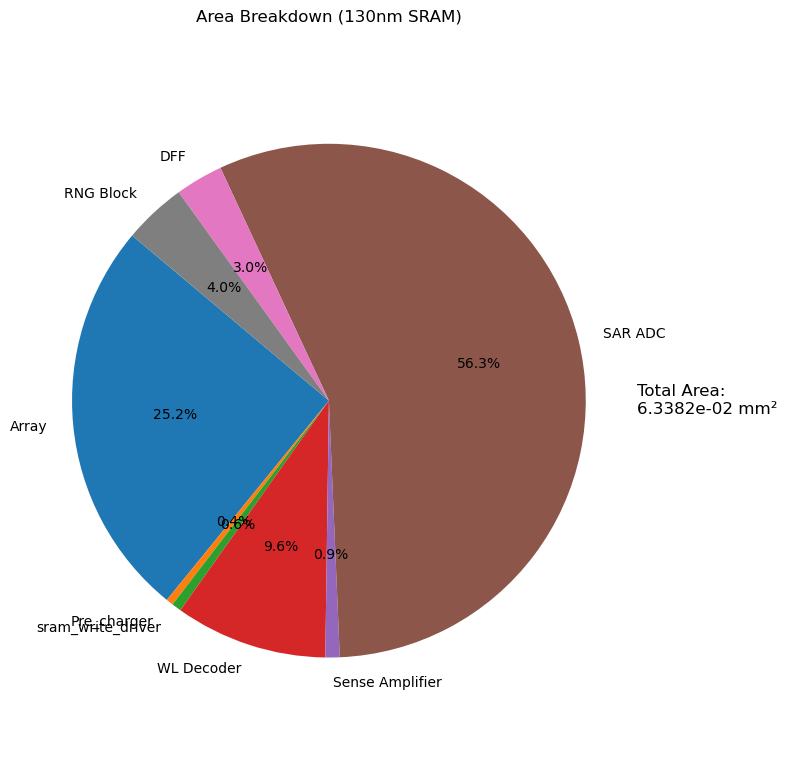

In [22]:
import matplotlib.pyplot as plt
# 各模块名称
labels = [
    'Array',
    'Pre_charger',
    'sram_write_driver',
    'WL Decoder',
    'MUX',
    'Sense Amplifier',
    'SAR ADC',
    'DFF',
    'RNG Block'
]

areas = [
    1.9382272e-08, 
    3.4524672e-10, 
    4.603289599999999e-10, 
    7.365263359999997e-09, 
    0,
    6.9049344e-10, 
    4.319522895827854e-08, 
    2.3016448e-09, 
    3.0331425279999997e-09
]


total_area = 0.06338230155367205
# 过滤掉面积为 0 的模块（例如 MUX）
filtered_labels = [label for label, area in zip(labels, areas) if area > 0]
filtered_areas = [area for area in areas if area > 0]

# 绘制饼图
plt.figure(figsize=(8, 8))
plt.pie(filtered_areas, labels=filtered_labels, autopct='%1.1f%%', startangle=140)
plt.title('Area Breakdown (130nm SRAM)')
plt.text(1.2, 0.0, f'Total Area:\n{total_area:.4e} mm²', fontsize=12, verticalalignment='center')
plt.axis('equal')  # 让饼图看起来是圆形的
plt.tight_layout()
plt.show()


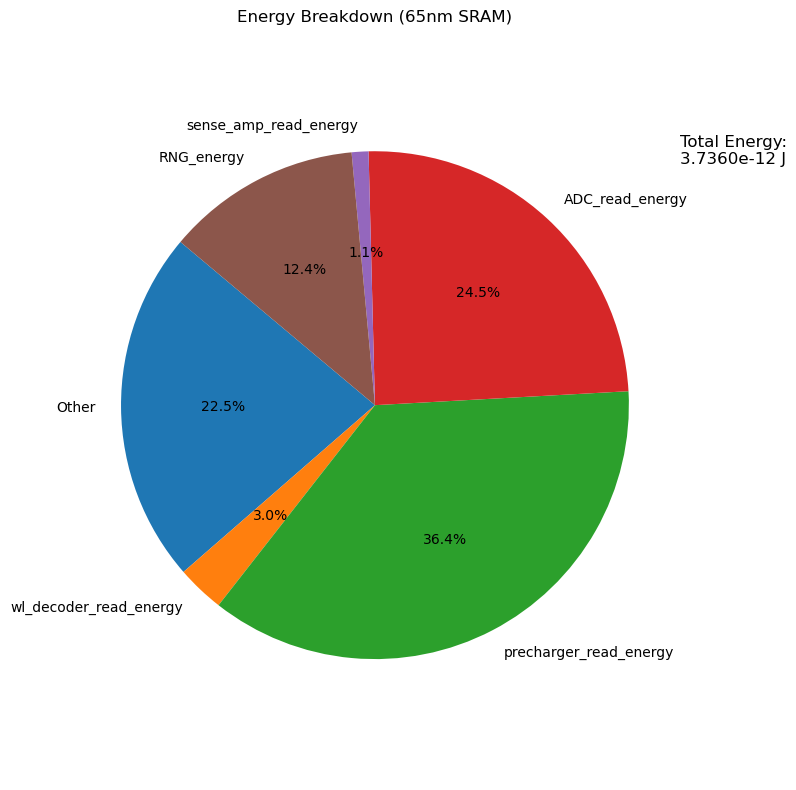

In [11]:
import matplotlib.pyplot as plt
# 各模块名称
labels = [
    'Other',
    'wl_decoder_read_energy',
    'precharger_read_energy',
    'ADC_read_energy',
    'sense_amp_read_energy',
    'mux',
    'RNG_energy',
]

areas = [
    3.73577014465829e-12, 
    5.035361139007878e-13, 
    6.045501392490431e-12, 
    4.0693080056073594e-12, 
    1.7719949105132184e-13,
    0,
    2.06063734088921e-12, 
]


total_area = 3.736e-12
# 过滤掉面积为 0 的模块（例如 MUX）
filtered_labels = [label for label, area in zip(labels, areas) if area > 0]
filtered_areas = [area for area in areas if area > 0]

# 绘制饼图
plt.figure(figsize=(8, 8))
plt.pie(filtered_areas, labels=filtered_labels, autopct='%1.1f%%', startangle=140)
plt.title('Energy Breakdown (65nm SRAM)')
plt.text(1.2, 1.0, f'Total Energy:\n{total_area:.4e} J', fontsize=12, verticalalignment='center')
plt.axis('equal')  # 让饼图看起来是圆形的
plt.tight_layout()
plt.show()


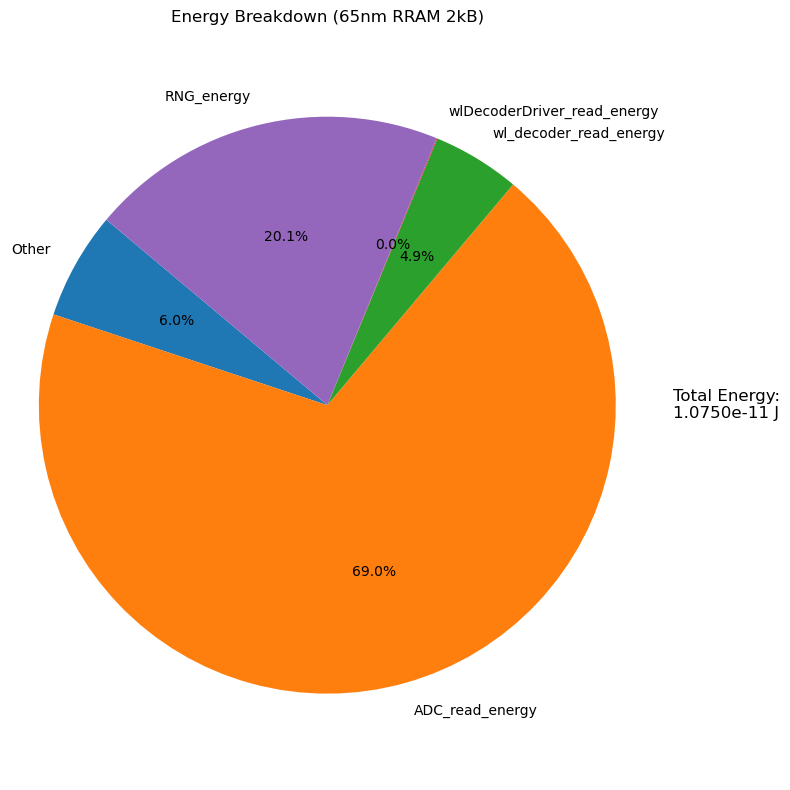

In [8]:
import matplotlib.pyplot as plt
# 各模块名称
labels = [
    'Other',
    'ADC_read_energy',
    'mux_read_energy',
    'wl_decoder_read_energy',
    'wlDecoderDriver_read_energy',
    'RNG_energy',
]

areas = [
    6.174297006364775e-13, 
    7.0775139908273805e-12, 
    0, 
    5.035361139007878e-13, 
    4.620123580253959e-15,
    2.06063734088921e-12, 
]


total_area = 1.075e-11
# 过滤掉面积为 0 的模块（例如 MUX）
filtered_labels = [label for label, area in zip(labels, areas) if area > 0]
filtered_areas = [area for area in areas if area > 0]

# 绘制饼图
plt.figure(figsize=(8, 8))
plt.pie(filtered_areas, labels=filtered_labels, autopct='%1.1f%%', startangle=140)
plt.title('Energy Breakdown (65nm RRAM 2kB)')
plt.text(1.2, 0.0, f'Total Energy:\n{total_area:.4e} J', fontsize=12, verticalalignment='center')
plt.axis('equal')  # 让饼图看起来是圆形的
plt.tight_layout()
plt.show()


=== Statistical Analysis of Data ===
Samples: 98
------------------------------------------------------------
Metric                       Result Ideal Gaussian Reference
------------------------------------------------------------
Mean                        0.00579                      ≈ 0
Std                         0.51142                      ≈ 1
Skewness                   -0.02309          ≈ 0 (Symmetric)
Kurtosis                    3.27643     ≈ 3 (Tail thickness)
K–S Test p-value            0.56255        > 0.05 → Good fit
Wasserstein Dist.           0.23891< 0.05 → Close to Gaussian
------------------------------------------------------------


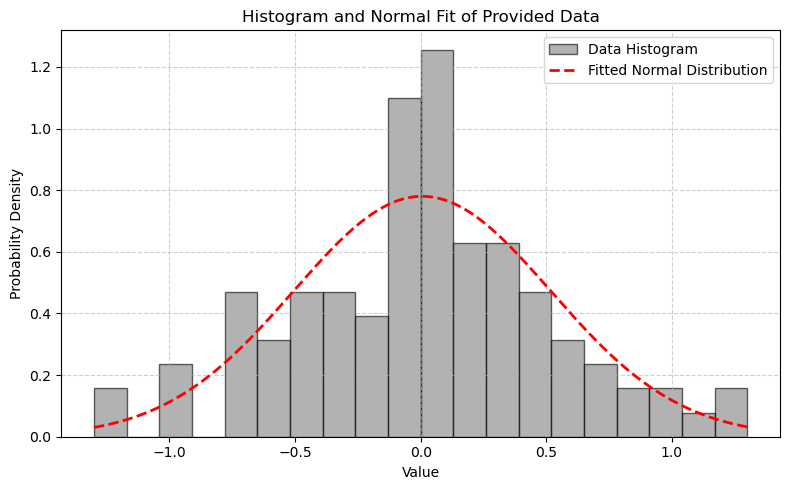

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, kstest, norm, wasserstein_distance

# ====== 数据 ======
# data = np.array([
# 0.5383809000, 0.5049773000, -0.0441768000, -0.0441768000, 0.4626662000, -0.7, -0.0063195000,
# 0.5791332000, 0.3444176000, 1.0710559000, 0.1431057000, -0.7, 0.7352390000, -1, -0.1312487000,
# -0.2612998000, -0.5884318000, 0.9376645000, 0.0642733000, 0.1143786000, -0.4699606000,
# -0.1094251000, -0.1138789000, 0.0609330000, -0.3657416000, 0.1716100000, 0.3555522000,
# 0.2179296000, 0.4332711000, -0.2421485000, -0.1802406000, 0.9641646000, 0.4457417000,
# 0.1217274000, -0.1043032000, -0.1982785000, 0.2373036000, 0.0898827000, 0.0789709000,
# 0.1535721000, 0.6653143000, 0.2617996000, 0.3553295000, -0.5414442000, -0.3677458000,
# 0.5617633000, 0.2201565000, -0.0853745000, -0.2519468000, -0.4316579000, -0.0056514000,
# -0.1094251000, -0.1020763000, 0.0021427000, 0.4793679000, 0.0649414000, 0.1446645000,
# -0.0497441000, -0.5291962000, -0.7, 0.0912188000, 0.3234848000, -0.4639480000, 0.1266266000,
# -0.1152150000, 0.2604634000, -0.2935899000, 0.6172132000, 0.4236954000, 0.7334575000,
# 0.1050256000, 0.8140714000, -0.4924523000, -1.3, 0.1814084000, -0.7, -0.4363344000,
# 0.7895755000, -0.1201142000, -0.7, -0.3038337000, -1, 0.3190310000, 1.3, 0.0440085000,
# -0.7, -0.5472341000, -0.1201142000, -0.0274751000, 0.3190310000, -0.4953473000, -1,
# -0.0508575000, 1.3, -0.2795604000, 0.1814084000, 0.2720433000, -1.3
# ])
data = np.array([
0.5383809000, 0.5049773000, -0.0441768000, 0, 0.4626662000, -0.7, -0.0063195000, 0.5791332000,
0.3444176000, 1.0710559000, 0.1431057000, -0.7, 0.7352390000, -1, -0.1312487000, -0.2612998000,
-0.5884318000, 0.9376645000, 0.0642733000, 0.1143786000, -0.4699606000, -0.1094251000,
-0.1138789000, 0.0609330000, -0.3657416000, 0.1716100000, 0.3555522000, 0.2179296000,
0.4332711000, -0.2421485000, -0.1802406000, 0.9641646000, 0.4457417000, 0.1217274000,
-0.1043032000, -0.1982785000, 0.2373036000, 0.0898827000, 0.0789709000, 0.1535721000,
0.6653143000, 0.2617996000, 0.3553295000, -0.5414442000, -0.3677458000, 0.5617633000,
0.2201565000, -0.0853745000, -0.2519468000, -0.4316579000, -0.0056514000, -0.1094251000,
-0.1020763000, 0.0021427000, 0.4793679000, 0.0649414000, 0.1446645000, -0.0497441000,
-0.5291962000, -0.7, 0.0912188000, 0.3234848000, -0.4639480000, 0.1266266000, -0.1152150000,
0.2604634000, -0.2935899000, 0.6172132000, 0.4236954000, 0.7334575000, 0.1050256000,
0.8140714000, -0.4924523000, -1.3, 0.1814084000, -0.7, -0.4363344000, 0.7895755000,
-0.1201142000, -0.7, -0.3038337000, -1, 0.3190310000, 1.3, 0.0440085000, -0.7, -0.5472341000,
0, -0.0274751000, 0, -0.4953473000, -1, -0.0508575000, 1.3, -0.2795604000, 0, 0.2720433000, -1.3
])

# ====== 基本统计特征 ======
mean_val = np.mean(data)
std_val = np.std(data)
skew_val = skew(data)
kurt_val = kurtosis(data, fisher=False)  # 使用 Pearson 定义，理想高斯=3
ks_stat, ks_p = kstest((data - mean_val) / std_val, 'norm')
ideal_data = np.random.normal(0, 1, len(data))
wasserstein_dist = wasserstein_distance((data - mean_val) / std_val, ideal_data)

# ====== 打印结果 ======
print("=== Statistical Analysis of Data ===")
print(f"Samples: {len(data)}")
print("-" * 60)
print(f"{'Metric':<20}{'Result':>15}{'Ideal Gaussian Reference':>25}")
print("-" * 60)
print(f"{'Mean':<20}{mean_val:>15.5f}{'≈ 0':>25}")
print(f"{'Std':<20}{std_val:>15.5f}{'≈ 1':>25}")
print(f"{'Skewness':<20}{skew_val:>15.5f}{'≈ 0 (Symmetric)':>25}")
print(f"{'Kurtosis':<20}{kurt_val:>15.5f}{'≈ 3 (Tail thickness)':>25}")
print(f"{'K–S Test p-value':<20}{ks_p:>15.5f}{'> 0.05 → Good fit':>25}")
print(f"{'Wasserstein Dist.':<20}{wasserstein_dist:>15.5f}{'< 0.05 → Close to Gaussian':>25}")
print("-" * 60)

# ====== 绘制直方图 + 理想高斯曲线 ======
plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, color='gray', edgecolor='black', label='Data Histogram')

x = np.linspace(np.min(data), np.max(data), 200)
pdf = norm.pdf(x, mean_val, std_val)
plt.plot(x, pdf, 'r--', linewidth=2, label='Fitted Normal Distribution')

plt.title("Histogram and Normal Fit of Provided Data")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [121]:
import numpy as np
from scipy.stats import norm, skew, kurtosis, kstest, wasserstein_distance, chisquare
import matplotlib.pyplot as plt

# ====== 参数设置 ======
num_samples = 10000     # 样本数量
num_uniforms = 4        # 叠加多少个均匀分布 (CLT参数)
quantization_bits = 16    # 模拟LFSR输出位宽（量化精度）

# ====== 生成原始均匀随机数 ======
uniforms = np.random.rand(num_uniforms, num_samples)

# ====== 模拟 LFSR 量化过程 ======
levels = 2 ** quantization_bits
uniforms_q = np.floor(uniforms * levels) / levels  # 均匀量化到 [0, 1)
print(f"Quantization bits: {quantization_bits}, Levels: {levels}")
print(f"Uniform sample range after quantization: [{np.min(uniforms_q):.4f}, {np.max(uniforms_q):.4f}]")

# ====== CLT 叠加生成伪高斯随机数 ======
clt_data = np.sum(uniforms_q, axis=0) - num_uniforms / 2  # 均值居中
clt_data = (clt_data - np.mean(clt_data)) / np.std(clt_data)  # 标准化为N(0,1)
print("CLT data dimension:", clt_data.shape)

# ====== 生成理想高斯随机数 ======
ideal_data = np.random.normal(0, 1, num_samples)


print("dimension of clt_data: ", clt_data.shape)


Quantization bits: 16, Levels: 65536
Uniform sample range after quantization: [0.0000, 1.0000]
CLT data dimension: (10000,)
dimension of clt_data:  (10000,)


=== CLT Gaussian Random Number Quality Analysis ===
Samples: 10000, Uniform distributions summed: 4
----------------------------------------------------------------------
Metric                            Result      Ideal Gaussian Reference
----------------------------------------------------------------------
Mean                            -0.00000                           ≈ 0
Standard Deviation               1.00000                           ≈ 1
Skewness                         0.01156               ≈ 0 (Symmetric)
Kurtosis                         2.63185          ≈ 3 (Tail thickness)
K–S Test p-value                 0.01448             > 0.05 → Good fit
Chi-square Test p-value          0.00009 > 0.05 → No significant diff.
Wasserstein Distance             0.02869< 0.05 → Close to ideal Gaussian
----------------------------------------------------------------------


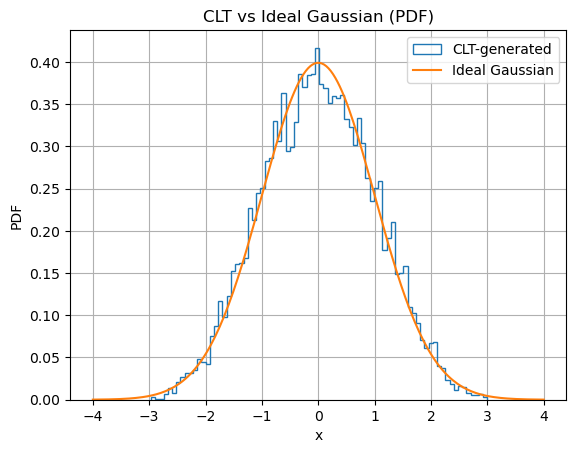

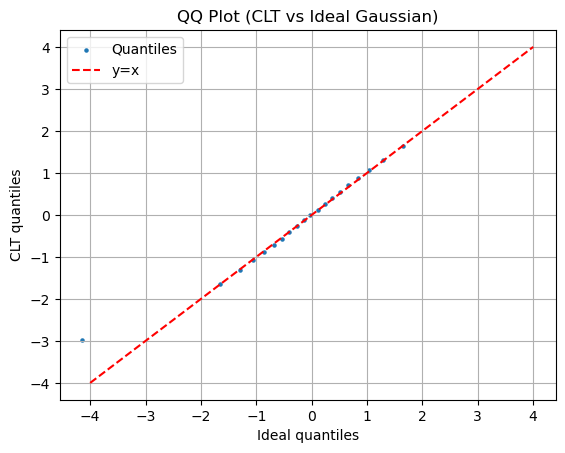

In [122]:
# ====== 基本统计指标 ======
mean_val = np.mean(clt_data)
std_val = np.std(clt_data)
skew_val = skew(clt_data)
kurt_val = kurtosis(clt_data, fisher=False)

# ====== 拟合优度检验 ======
ks_stat, ks_p = kstest(clt_data, 'norm')
chi_hist, bin_edges = np.histogram(clt_data, bins=50)
expected = len(clt_data) * np.diff(norm.cdf(bin_edges))
expected *= chi_hist.sum() / expected.sum()
chi_stat, chi_p = chisquare(chi_hist, expected)

# ====== Wasserstein 距离 ======
wasserstein_dist = wasserstein_distance(clt_data, ideal_data)

# ====== Print results (with reference indicators) ======
print("=== CLT Gaussian Random Number Quality Analysis ===")
print(f"Samples: {num_samples}, Uniform distributions summed: {num_uniforms}")
print("-" * 70)
print(f"{'Metric':<25}{'Result':>15}{'Ideal Gaussian Reference':>30}")
print("-" * 70)
print(f"{'Mean':<25}{mean_val:>15.5f}{'≈ 0':>30}")
print(f"{'Standard Deviation':<25}{std_val:>15.5f}{'≈ 1':>30}")
print(f"{'Skewness':<25}{skew_val:>15.5f}{'≈ 0 (Symmetric)':>30}")
print(f"{'Kurtosis':<25}{kurt_val:>15.5f}{'≈ 3 (Tail thickness)':>30}")
print(f"{'K–S Test p-value':<25}{ks_p:>15.5f}{'> 0.05 → Good fit':>30}")
print(f"{'Chi-square Test p-value':<25}{chi_p:>15.5f}{'> 0.05 → No significant diff.':>30}")
print(f"{'Wasserstein Distance':<25}{wasserstein_dist:>15.5f}{'< 0.05 → Close to ideal Gaussian':>30}")
print("-" * 70)

# ====== 绘制可视化 ======
plt.figure()
plt.title("CLT vs Ideal Gaussian (PDF)")
plt.hist(clt_data, bins=80, density=True, histtype='step', label='CLT-generated')
x = np.linspace(-4, 4, 200)
plt.plot(x, norm.pdf(x), label='Ideal Gaussian')
plt.legend()
plt.xlabel("x")
plt.ylabel("PDF")
plt.grid()

plt.figure()
plt.title("QQ Plot (CLT vs Ideal Gaussian)")
theoretical_quantiles = np.quantile(ideal_data, np.linspace(0, 1, num_samples))
sample_quantiles = np.quantile(clt_data, np.linspace(0, 1, num_samples))
plt.scatter(theoretical_quantiles[::500], sample_quantiles[::500], s=5, label="Quantiles")
plt.plot([-4, 4], [-4, 4], 'r--', label="y=x")
plt.legend()
plt.xlabel("Ideal quantiles")
plt.ylabel("CLT quantiles")
plt.grid()

plt.show()

maen:  0.012084534471635076
std:  0.998779580977917
dimension of customized_gaussian_current:  (800,)
=== Analog Gaussian Random Number Quality Analysis ===
----------------------------------------------------------------------
Metric                            Result      Ideal Gaussian Reference
----------------------------------------------------------------------
Mean                             0.01208                           ≈ 0
Standard Deviation               0.99878                           ≈ 1
Skewness                         0.07180               ≈ 0 (Symmetric)
Kurtosis                         2.80303          ≈ 3 (Tail thickness)
K–S Test p-value                 0.89529             > 0.05 → Good fit
Chi-square Test p-value          0.27280 > 0.05 → No significant diff.
Wasserstein Distance             0.03719< 0.05 → Close to ideal Gaussian
----------------------------------------------------------------------


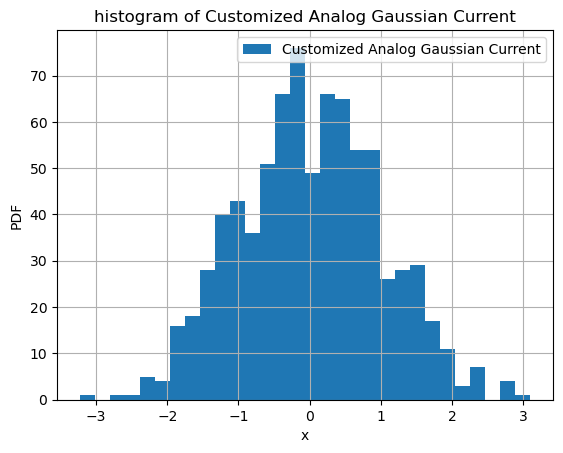

In [379]:
import pandas as pd
import scipy.stats as stats
filename = './Data/currents_vlsi.csv'
# filename = './Data/customized_gaussian_current.csv'
# filename = './Data/modified_chips_gaussian_current.csv'
df = pd.read_csv(filename, header=None)
customized_gaussian_current = df.to_numpy()

# # 读取 CSV 文件，保留列名
# filename = './Data/Copy of Final GRNG Values - Discharge - Raw.csv'
# filename = './Data/Copy of Final GRNG Values - Charge - Raw.csv'
# df = pd.read_csv(filename)


# # 打印列名以确认
# print("Columns in CSV:", df.columns.tolist())

# # === 选择目标列（例如列名为 'current_value'）===
# column_name = '0.475_p'   # 👈 改成你要选择的列名
# if column_name not in df.columns:
#     raise ValueError(f"Error: Column '{column_name}' not found in CSV file.")

# customized_gaussian_current = df[column_name].to_numpy()

# # 防止空数组
# if len(customized_gaussian_current) == 0:
#     raise ValueError("Input array contains only NaN or inf values.")

# # 确认标准差非零（避免除零）
# if np.std(customized_gaussian_current) == 0:
#     raise ValueError("All input values are identical; cannot normalize or compute histogram.")

#normalize to standard normal distribution
customized_gaussian_current = (customized_gaussian_current - np.mean(customized_gaussian_current)) / np.std(customized_gaussian_current)
customized_gaussian_current = customized_gaussian_current[np.abs(customized_gaussian_current) < 3.5]

customized_gaussian_current = np.random.choice(customized_gaussian_current, 800, replace=False)

# histogram = plt.hist(customized_gaussian_current, bins=20)
print("maen: ", np.mean(customized_gaussian_current))
print("std: ", np.std(customized_gaussian_current))
customized_gaussian_current = customized_gaussian_current.flatten()
print("dimension of customized_gaussian_current: ", customized_gaussian_current.shape)

# ====== 基本统计指标 ======
mean_val = np.mean(customized_gaussian_current)
std_val = np.std(customized_gaussian_current)
skew_val = skew(customized_gaussian_current)
kurt_val = kurtosis(customized_gaussian_current, fisher=False)

# ====== 拟合优度检验 ======
ks_stat, ks_p = kstest(customized_gaussian_current, 'norm')
chi_hist, bin_edges = np.histogram(customized_gaussian_current, bins=50)
expected = len(customized_gaussian_current) * np.diff(norm.cdf(bin_edges))
expected *= chi_hist.sum() / expected.sum()
chi_stat, chi_p = chisquare(chi_hist, expected)

# ====== Wasserstein 距离 ======
wasserstein_dist = wasserstein_distance(customized_gaussian_current, ideal_data)

# ====== Print results (with reference indicators) ======
print("=== Analog Gaussian Random Number Quality Analysis ===")
print("-" * 70)
print(f"{'Metric':<25}{'Result':>15}{'Ideal Gaussian Reference':>30}")
print("-" * 70)
print(f"{'Mean':<25}{mean_val:>15.5f}{'≈ 0':>30}")
print(f"{'Standard Deviation':<25}{std_val:>15.5f}{'≈ 1':>30}")
print(f"{'Skewness':<25}{skew_val:>15.5f}{'≈ 0 (Symmetric)':>30}")
print(f"{'Kurtosis':<25}{kurt_val:>15.5f}{'≈ 3 (Tail thickness)':>30}")
print(f"{'K–S Test p-value':<25}{ks_p:>15.5f}{'> 0.05 → Good fit':>30}")
print(f"{'Chi-square Test p-value':<25}{chi_p:>15.5f}{'> 0.05 → No significant diff.':>30}")
print(f"{'Wasserstein Distance':<25}{wasserstein_dist:>15.5f}{'< 0.05 → Close to ideal Gaussian':>30}")
print("-" * 70)

# ====== 绘制可视化 ======
plt.figure()
plt.title("histogram of Customized Analog Gaussian Current")
plt.hist(customized_gaussian_current, bins=30, label='Customized Analog Gaussian Current')
plt.legend()
plt.xlabel("x")
plt.ylabel("PDF")
plt.grid()

# ---------- pulse_width Q-Q Plot ----------
# plt.figure(figsize=(6, 6))

# osm = stats.probplot(customized_gaussian_current, dist="norm")
# theoretical_q = osm[0][0]  
# ordered_data = osm[0][1]   

# slope, intercept, r_value, p_value, std_err = stats.linregress(theoretical_q, ordered_data)

# plt.plot(theoretical_q, ordered_data, 'o', label='Data')
# plt.plot(theoretical_q, slope * np.array(theoretical_q) + intercept, 'r--', label=f'Fit line (R={r_value:.4f})')
# plt.xlabel('Theoretical Quantiles')
# plt.ylabel('Ordered Values')
# plt.title('Q-Q Plot of Pulse Widths')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()


plt.show()

[CLT2] Done: Wasserstein = 0.0441, KS_p = 0.0000
[CLT4] Done: Wasserstein = 0.0167, KS_p = 0.0001
[CLT6] Done: Wasserstein = 0.0087, KS_p = 0.0137
[CLT8] Done: Wasserstein = 0.0118, KS_p = 0.0227
[CLT10] Done: Wasserstein = 0.0078, KS_p = 0.2435
[CLT12] Done: Wasserstein = 0.0113, KS_p = 0.1178
[CLT14] Done: Wasserstein = 0.0057, KS_p = 0.3101
[CLT16] Done: Wasserstein = 0.0102, KS_p = 0.6141


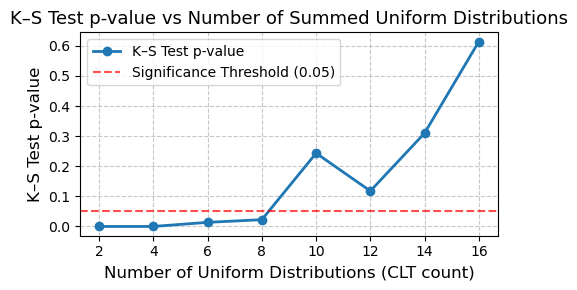

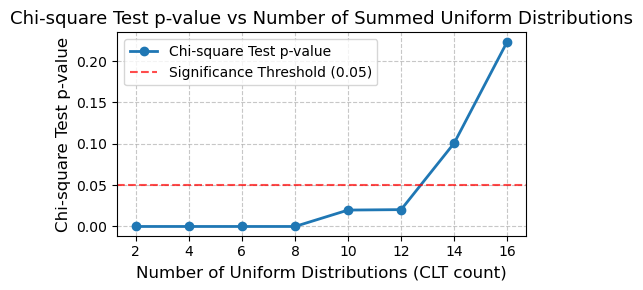

In [104]:
import numpy as np
from scipy.stats import norm, skew, kurtosis, kstest, wasserstein_distance, chisquare
import matplotlib.pyplot as plt

# ===== 参数设置 =====
num_samples = 80000
quantization_bits = 16
uniform_counts = [2, 4, 6, 8, 10, 12, 14, 16]

# ===== 存储结果 =====
metrics = {
    "Mean": [],
    "Std": [],
    "Skewness": [],
    "Kurtosis": [],
    "KS_p": [],
    "Wasserstein": [],
    "chi_p": []
}

# ===== 扫描不同的 num_uniforms =====
for num_uniforms in uniform_counts:
    # --- 生成均匀随机数 ---
    uniforms = np.random.rand(num_uniforms, num_samples)

    # --- 模拟量化（模拟LFSR输出） ---
    levels = 2 ** quantization_bits
    uniforms_q = np.floor(uniforms * levels) / levels

    # --- CLT 叠加 ---
    clt_data = np.sum(uniforms_q, axis=0) - num_uniforms / 2
    clt_data = (clt_data - np.mean(clt_data)) / np.std(clt_data)

    # --- 理想高斯样本 ---
    ideal_data = np.random.normal(0, 1, num_samples)

    # --- 计算指标 ---
    mean_val = np.mean(clt_data)
    std_val = np.std(clt_data)
    skew_val = skew(clt_data)
    kurt_val = kurtosis(clt_data, fisher=False)
    ks_stat, ks_p = kstest(clt_data, 'norm')
    wasserstein_dist = wasserstein_distance(clt_data, ideal_data)
    # --- chip-square 检验 ---
    chi_hist, bin_edges = np.histogram(clt_data, bins=50)
    expected = len(clt_data) * np.diff(norm.cdf(bin_edges))
    expected *= chi_hist.sum() / expected.sum()
    chi_stat, chi_p = chisquare(chi_hist, expected)

    # --- 保存结果 ---
    metrics["Mean"].append(mean_val)
    metrics["Std"].append(std_val)
    metrics["Skewness"].append(skew_val)
    metrics["Kurtosis"].append(kurt_val)
    metrics["KS_p"].append(ks_p)
    metrics["chi_p"].append(chi_p)
    metrics["Wasserstein"].append(wasserstein_dist)

    print(f"[CLT{num_uniforms}] Done: Wasserstein = {wasserstein_dist:.4f}, KS_p = {ks_p:.4f}")

# ===== 绘图部分 =====
# plt.figure(figsize=(5, 3))
# plt.plot(uniform_counts, metrics["Wasserstein"], marker='o', linewidth=2, label='Wasserstein Distance')
# # plt.plot(uniform_counts, metrics["KS_p"], marker='s', linewidth=2, label='K–S Test p-value')
# plt.xlabel('Number of Uniform Distributions (CLT count)', fontsize=12)
# plt.ylabel('Metric Value', fontsize=12)
# plt.title('CLT Convergence Metrics vs Number of Summed Uniform Distributions', fontsize=13)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# # ===== 可选：画出形状指标 (Skewness, Kurtosis) =====
# plt.figure(figsize=(10, 6))
# plt.plot(uniform_counts, metrics["Skewness"], marker='o', linewidth=2, label='Skewness')
# plt.plot(uniform_counts, metrics["Kurtosis"], marker='s', linewidth=2, label='Kurtosis')
# plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
# plt.axhline(3, color='gray', linestyle='--', alpha=0.5)
# plt.xlabel('Number of Uniform Distributions (CLT count)', fontsize=12)
# plt.ylabel('Shape Metrics', fontsize=12)
# plt.title('CLT Gaussian Shape Metrics vs Number of Summed Uniform Distributions', fontsize=13)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(5, 3))
plt.plot(uniform_counts, metrics["KS_p"], marker='o', linewidth=2, label='K–S Test p-value')
plt.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='Significance Threshold (0.05)')
plt.xlabel('Number of Uniform Distributions (CLT count)', fontsize=12)
plt.ylabel('K–S Test p-value', fontsize=12)
plt.title('K–S Test p-value vs Number of Summed Uniform Distributions', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(uniform_counts, metrics["chi_p"], marker='o', linewidth=2, label='Chi-square Test p-value')
plt.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='Significance Threshold (0.05)')
plt.xlabel('Number of Uniform Distributions (CLT count)', fontsize=12)
plt.ylabel('Chi-square Test p-value', fontsize=12)
plt.title('Chi-square Test p-value vs Number of Summed Uniform Distributions', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

[CLT2] Avg over 50 runs -> KS_p = 0.0023, Chi_p = 0.0000, Wasserstein = 0.04726
[CLT4] Avg over 50 runs -> KS_p = 0.2115, Chi_p = 0.1096, Wasserstein = 0.02437
[CLT6] Avg over 50 runs -> KS_p = 0.4825, Chi_p = 0.4204, Wasserstein = 0.01921
[CLT8] Avg over 50 runs -> KS_p = 0.5045, Chi_p = 0.4285, Wasserstein = 0.01818
[CLT10] Avg over 50 runs -> KS_p = 0.6480, Chi_p = 0.4598, Wasserstein = 0.01753
[CLT12] Avg over 50 runs -> KS_p = 0.6949, Chi_p = 0.5283, Wasserstein = 0.01687
[CLT14] Avg over 50 runs -> KS_p = 0.6952, Chi_p = 0.4214, Wasserstein = 0.01581
[CLT16] Avg over 50 runs -> KS_p = 0.7286, Chi_p = 0.5307, Wasserstein = 0.01550


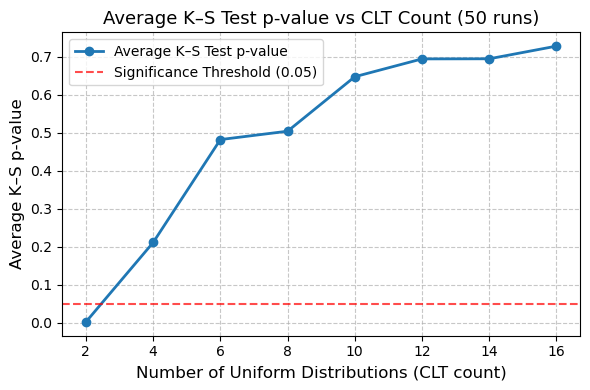

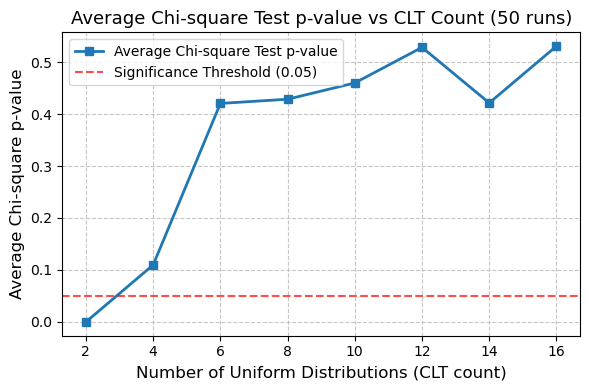

In [118]:
import numpy as np
from scipy.stats import norm, skew, kurtosis, kstest, wasserstein_distance, chisquare
import matplotlib.pyplot as plt

# ===== 参数设置 =====
num_samples = 10000          # 每次实验的样本数量
quantization_bits = 16       # 模拟LFSR量化位宽
uniform_counts = [2, 4, 6, 8, 10, 12, 14, 16]  # CLT叠加数量
num_repeats = 50             # 重复次数（取平均）

# ===== 存储平均结果 =====
avg_metrics = {
    "KS_p": [],
    "chi_p": [],
    "Wasserstein": []
}

# ===== 主循环（重复实验） =====
for num_uniforms in uniform_counts:
    ks_p_list = []
    chi_p_list = []
    wass_list = []

    for rep in range(num_repeats):
        # --- 生成均匀随机数 ---
        uniforms = np.random.rand(num_uniforms, num_samples)

        # --- 模拟LFSR量化 ---
        levels = 2 ** quantization_bits
        uniforms_q = np.floor(uniforms * levels) / levels

        # --- CLT叠加生成伪高斯 ---
        clt_data = np.sum(uniforms_q, axis=0) - num_uniforms / 2
        clt_data = (clt_data - np.mean(clt_data)) / np.std(clt_data)

        # --- 理想高斯样本 ---
        ideal_data = np.random.normal(0, 1, num_samples)

        # --- K–S 检验 ---
        ks_stat, ks_p = kstest(clt_data, 'norm')

        # --- Chi-square 检验 ---
        chi_hist, bin_edges = np.histogram(clt_data, bins=50)
        expected = len(clt_data) * np.diff(norm.cdf(bin_edges))
        expected *= chi_hist.sum() / expected.sum()
        chi_stat, chi_p = chisquare(chi_hist, expected)

        # --- Wasserstein 距离 ---
        wass = wasserstein_distance(clt_data, ideal_data)

        # --- 保存本轮结果 ---
        ks_p_list.append(ks_p)
        chi_p_list.append(chi_p)
        wass_list.append(wass)

    # --- 计算平均结果 ---
    avg_metrics["KS_p"].append(np.mean(ks_p_list))
    avg_metrics["chi_p"].append(np.mean(chi_p_list))
    avg_metrics["Wasserstein"].append(np.mean(wass_list))

    print(f"[CLT{num_uniforms}] Avg over {num_repeats} runs -> "
          f"KS_p = {np.mean(ks_p_list):.4f}, Chi_p = {np.mean(chi_p_list):.4f}, Wasserstein = {np.mean(wass_list):.5f}")

# ===== 绘制平均结果 =====

plt.figure(figsize=(6, 4))
plt.plot(uniform_counts, avg_metrics["KS_p"], marker='o', linewidth=2, label='Average K–S Test p-value')
plt.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='Significance Threshold (0.05)')
plt.xlabel('Number of Uniform Distributions (CLT count)', fontsize=12)
plt.ylabel('Average K–S p-value', fontsize=12)
plt.title(f'Average K–S Test p-value vs CLT Count ({num_repeats} runs)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(uniform_counts, avg_metrics["chi_p"], marker='s', linewidth=2, label='Average Chi-square Test p-value')
plt.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='Significance Threshold (0.05)')
plt.xlabel('Number of Uniform Distributions (CLT count)', fontsize=12)
plt.ylabel('Average Chi-square p-value', fontsize=12)
plt.title(f'Average Chi-square Test p-value vs CLT Count ({num_repeats} runs)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(6, 4))
# plt.plot(uniform_counts, avg_metrics["Wasserstein"], marker='^', linewidth=2, label='Average Wasserstein Distance')
# plt.xlabel('Number of Uniform Distributions (CLT count)', fontsize=12)
# plt.ylabel('Average Wasserstein Distance', fontsize=12)
# plt.title(f'Average Wasserstein Distance vs CLT Count ({num_repeats} runs)', fontsize=13)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

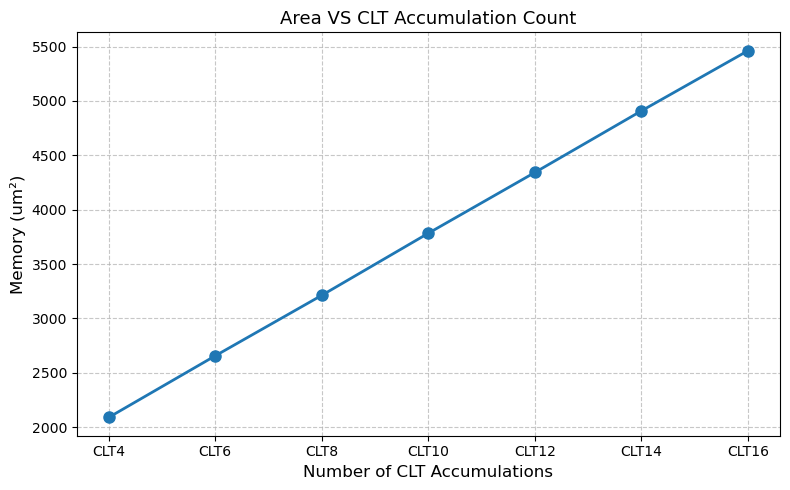

In [129]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 CLT 叠加数量（单位：kB）
memory_sizes = ['CLT4', 'CLT6', 'CLT8', 'CLT10', 'CLT12', 'CLT14', 'CLT16']

# 对应的 Memory Density（bit/mm²）
bits_per_mm2_sram = [2090.879954, 2657.159938, 3213.359921, 3783.959905, 
                     4342.679888, 4908.959871, 5461.919853]

# 数值索引
x = np.arange(len(memory_sizes))

# 绘制折线图
plt.figure(figsize=(8, 5))
plt.plot(x, bits_per_mm2_sram, marker='o', linewidth=2, markersize=8)

# 设置坐标轴标签与标题
plt.xticks(x, memory_sizes)
plt.xlabel('Number of CLT Accumulations', fontsize=12)
plt.ylabel('Memory (um²)', fontsize=12)
plt.title('Area VS CLT Accumulation Count', fontsize=13)

# 网格与样式
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 显示图形
plt.show()

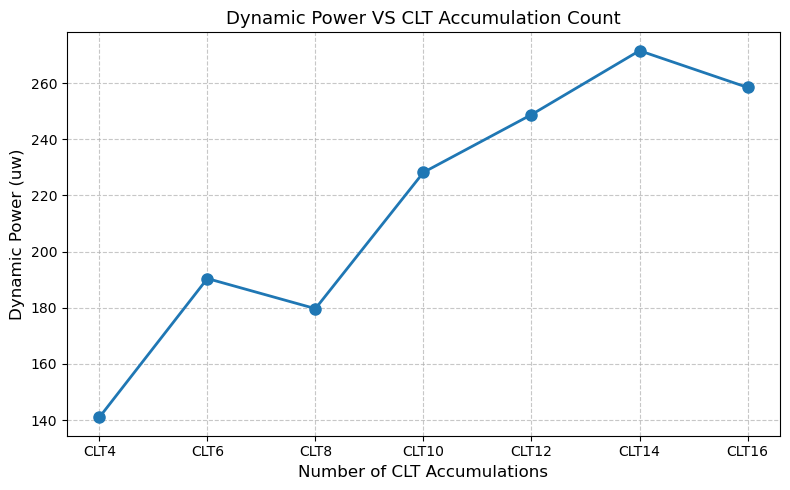

In [133]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 CLT 叠加数量（单位：kB）
memory_sizes = ['CLT4', 'CLT6', 'CLT8', 'CLT10', 'CLT12', 'CLT14', 'CLT16']

# 对应的 Memory Density（bit/mm²）
bits_per_mm2_sram = [140.9678, 190.4046, 179.6840, 228.2045, 
                     248.7693, 271.5370, 258.4441]

# 数值索引
x = np.arange(len(memory_sizes))

# 绘制折线图
plt.figure(figsize=(8, 5))
plt.plot(x, bits_per_mm2_sram, marker='o', linewidth=2, markersize=8)

# 设置坐标轴标签与标题
plt.xticks(x, memory_sizes)
plt.xlabel('Number of CLT Accumulations', fontsize=12)
plt.ylabel('Dynamic Power (uw)', fontsize=12)
plt.title('Dynamic Power VS CLT Accumulation Count', fontsize=13)

# 网格与样式
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 显示图形
plt.show()

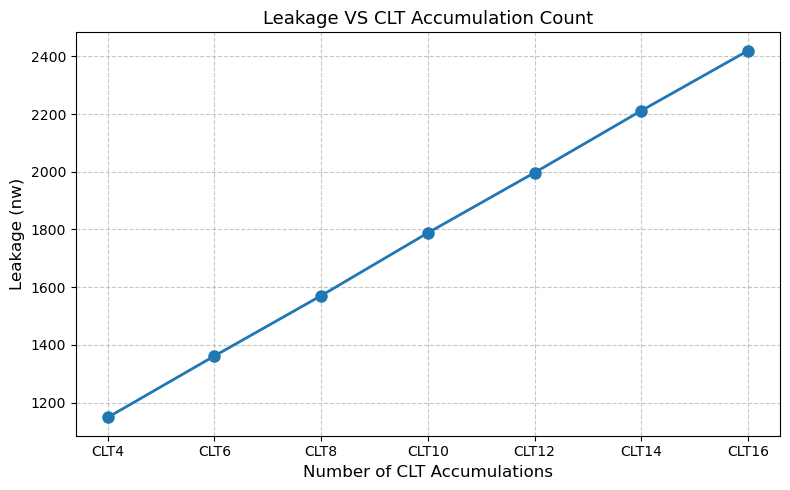

In [134]:
import matplotlib.pyplot as plt
import numpy as np

# 不同 CLT 叠加数量（单位：kB）
memory_sizes = ['CLT4', 'CLT6', 'CLT8', 'CLT10', 'CLT12', 'CLT14', 'CLT16']

# 对应的 Memory Density（bit/mm²）
bits_per_mm2_sram = [1.1485e+03, 1.3616e+03, 1.5706e+03, 1.7883e+03, 
                     1.9971e+03, 2.2119e+03, 2.4200e+03]

# 数值索引
x = np.arange(len(memory_sizes))

# 绘制折线图
plt.figure(figsize=(8, 5))
plt.plot(x, bits_per_mm2_sram, marker='o', linewidth=2, markersize=8)

# 设置坐标轴标签与标题
plt.xticks(x, memory_sizes)
plt.xlabel('Number of CLT Accumulations', fontsize=12)
plt.ylabel('Leakage (nw)', fontsize=12)
plt.title('Leakage VS CLT Accumulation Count', fontsize=13)

# 网格与样式
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 显示图形
plt.show()

maen:  -0.006890807876616174
std:  1.0206084867687748
dimension of customized_gaussian_current:  (100,)
=== Analog Gaussian Random Number Quality Analysis ===
----------------------------------------------------------------------
Metric                            Result      Ideal Gaussian Reference
----------------------------------------------------------------------
Mean                            -0.00689                           ≈ 0
Standard Deviation               1.02061                           ≈ 1
Skewness                         0.04426               ≈ 0 (Symmetric)
Kurtosis                         2.72905          ≈ 3 (Tail thickness)
K–S Test p-value                 0.75739             > 0.05 → Good fit
Chi-square Test p-value          0.70710 > 0.05 → No significant diff.
Wasserstein Distance             0.06716< 0.05 → Close to ideal Gaussian
----------------------------------------------------------------------


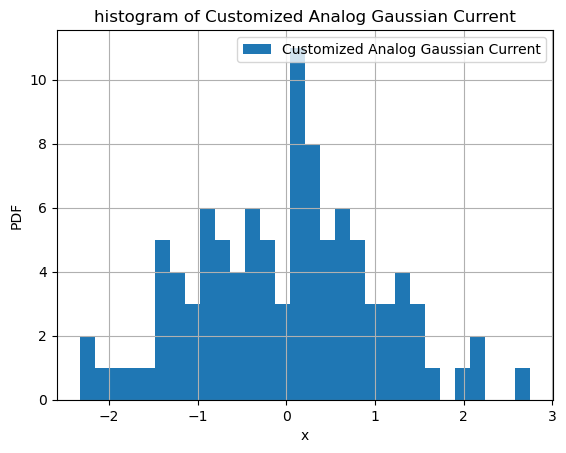

In [388]:
import pandas as pd
import scipy.stats as stats
# filename = './Data/Read1_0.xlsx'
# filename = './Data/customized_gaussian_current.csv'
# filename = './Data/modified_chips_gaussian_current.csv'
filename = './Data/Read1_0.csv'
# 跳过第一行（header 不是列名，只是无用内容）
df = pd.read_csv(filename, header=None, skiprows=1)

# 直接取第一列，并转成 float
customized_gaussian_current = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().to_numpy()


# # 读取 CSV 文件，保留列名
# filename = './Data/Copy of Final GRNG Values - Discharge - Raw.csv'
# filename = './Data/Copy of Final GRNG Values - Charge - Raw.csv'
# df = pd.read_csv(filename)


#normalize to standard normal distribution
customized_gaussian_current = (customized_gaussian_current - np.mean(customized_gaussian_current)) / np.std(customized_gaussian_current)
customized_gaussian_current = customized_gaussian_current[np.abs(customized_gaussian_current) < 3.5]

customized_gaussian_current = np.random.choice(customized_gaussian_current, 100, replace=False)

# histogram = plt.hist(customized_gaussian_current, bins=20)
print("maen: ", np.mean(customized_gaussian_current))
print("std: ", np.std(customized_gaussian_current))
customized_gaussian_current = customized_gaussian_current.flatten()
print("dimension of customized_gaussian_current: ", customized_gaussian_current.shape)

# ====== 基本统计指标 ======
mean_val = np.mean(customized_gaussian_current)
std_val = np.std(customized_gaussian_current)
skew_val = skew(customized_gaussian_current)
kurt_val = kurtosis(customized_gaussian_current, fisher=False)

# ====== 拟合优度检验 ======
ks_stat, ks_p = kstest(customized_gaussian_current, 'norm')
chi_hist, bin_edges = np.histogram(customized_gaussian_current, bins=50)
expected = len(customized_gaussian_current) * np.diff(norm.cdf(bin_edges))
expected *= chi_hist.sum() / expected.sum()
chi_stat, chi_p = chisquare(chi_hist, expected)

# ====== Wasserstein 距离 ======
wasserstein_dist = wasserstein_distance(customized_gaussian_current, ideal_data)

# ====== Print results (with reference indicators) ======
print("=== Analog Gaussian Random Number Quality Analysis ===")
print("-" * 70)
print(f"{'Metric':<25}{'Result':>15}{'Ideal Gaussian Reference':>30}")
print("-" * 70)
print(f"{'Mean':<25}{mean_val:>15.5f}{'≈ 0':>30}")
print(f"{'Standard Deviation':<25}{std_val:>15.5f}{'≈ 1':>30}")
print(f"{'Skewness':<25}{skew_val:>15.5f}{'≈ 0 (Symmetric)':>30}")
print(f"{'Kurtosis':<25}{kurt_val:>15.5f}{'≈ 3 (Tail thickness)':>30}")
print(f"{'K–S Test p-value':<25}{ks_p:>15.5f}{'> 0.05 → Good fit':>30}")
print(f"{'Chi-square Test p-value':<25}{chi_p:>15.5f}{'> 0.05 → No significant diff.':>30}")
print(f"{'Wasserstein Distance':<25}{wasserstein_dist:>15.5f}{'< 0.05 → Close to ideal Gaussian':>30}")
print("-" * 70)

# ====== 绘制可视化 ======
plt.figure()
plt.title("histogram of Customized Analog Gaussian Current")
plt.hist(customized_gaussian_current, bins=30, label='Customized Analog Gaussian Current')
plt.legend()
plt.xlabel("x")
plt.ylabel("PDF")
plt.grid()

# ---------- pulse_width Q-Q Plot ----------
# plt.figure(figsize=(6, 6))

# osm = stats.probplot(customized_gaussian_current, dist="norm")
# theoretical_q = osm[0][0]  
# ordered_data = osm[0][1]   

# slope, intercept, r_value, p_value, std_err = stats.linregress(theoretical_q, ordered_data)

# plt.plot(theoretical_q, ordered_data, 'o', label='Data')
# plt.plot(theoretical_q, slope * np.array(theoretical_q) + intercept, 'r--', label=f'Fit line (R={r_value:.4f})')
# plt.xlabel('Theoretical Quantiles')
# plt.ylabel('Ordered Values')
# plt.title('Q-Q Plot of Pulse Widths')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()


plt.show()